# Statistical vs. Process-Model Forecasting Skill

Compare the Bayesian rate-and-state GMSL–GMST model against IPCC AR6 process-model projections.

**Contents:**
1. Data loading and baseline alignment (year 2000)
2. Observed GMSL + GMST twin-axis time series
3. Two-panel projection comparison with societal impact axes
4. Hindcast cross-validation

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FuncFormatter
import json
import sys
import os
import warnings

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from slr_analysis import calibrate_dols, compute_kinematics, resample_to_monthly
from slr_data_readers import (
    people_displaced_kulpstrauss2019,
    slr_cost_jevrejeva2018,
)
from slr_projections import project_gmsl_ensemble, project_gmsl_state_ensemble
from bayesian_dols import solve_state_ode, build_level_design_vectors, fit_bayesian_level

warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

M_TO_MM = 1000.0
BASELINE_YEAR = 2000.0
N_SAMPLES = 2000

print('Imports loaded.')

Imports loaded.


## 1. Load Data and Baseline to Year 2000

In [105]:
# ============================================================
# Load all data from HDF5 store
# ============================================================
h5_path = '../data/processed/slr_processed_data.h5'

with pd.HDFStore(h5_path, 'r') as store:
    df_frederikse = store['/harmonized/df_frederikse_h']
    df_berkeley = store['/harmonized/df_berkeley_h']
    df_nasa_gmsl = store['/harmonized/df_nasa_gmsl_h']
    df_horwath = store['/harmonized/df_horwath_h']

    nasa_gmsl_kinematics = store['kinematics/gmsl/nasa']

    temp_projections = {}
    ssp_keys = {
        'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
        'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
    }
    for name, key in ssp_keys.items():
        temp_projections[name] = store[f'/projections/temp/{key}']

    ipcc_gmsl = {}
    ssp_gmsl_keys = {
        'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
        'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
    }
    for name, key in ssp_gmsl_keys.items():
        ipcc_gmsl[name] = store[f'/projections/gmsl/{key}']

# ============================================================
# Prepare Frederikse GMSL — rebase to year 2000 = 0
# ============================================================
fred_time = df_frederikse['year'].values
fred_gmsl = df_frederikse['gmsl'].values          # meters, baseline 1995-2005
fred_gmsl_sigma = df_frederikse['gmsl_sigma'].values

nasa_time = df_nasa_gmsl['decimal_year'].values
nasa_gmsl = df_nasa_gmsl['gmsl'].values 
nasa_gmsl_sigma = df_nasa_gmsl['gmsl_sigma'].values
nasa_gmsl_smooth = df_nasa_gmsl['gmsl'].rolling(20, center=True, min_periods=10).mean()

horw_time = df_horwath['decimal_year'].values
horw_gmsl = df_horwath['gmsl'].values          # meters, baseline 1995-2005
horw_gmsl_sigma = df_horwath['gmsl_sigma'].values
horw_gmsl_smooth = df_horwath['gmsl'].rolling(20, center=True, min_periods=10).mean()

idx_2000 = np.argmin(np.abs(fred_time - BASELINE_YEAR))
fred_gmsl_2000 = fred_gmsl[idx_2000]
fred_gmsl_rb = fred_gmsl - fred_gmsl_2000          # year 2000 ≈ 0

idx_2000 = np.argmin(np.abs(horw_time - BASELINE_YEAR))
horw_gmsl_2000 = horw_gmsl[idx_2000]
horw_gmsl_rb = horw_gmsl - horw_gmsl_2000
horw_gmsl_smooth_2000 = horw_gmsl_smooth[idx_2000]
horw_gmsl_smooth_rb = horw_gmsl_smooth - horw_gmsl_smooth_2000

print(f'Frederikse: {len(fred_time)} years, '
      f'{fred_time[0]:.0f}–{fred_time[-1]:.0f}')
print(f'GMSL at year 2000 (before rebase): {fred_gmsl_2000*M_TO_MM:.1f} mm')

# ============================================================
# Prepare Berkeley Earth GMST — rebase to year 2000 = 0
# ============================================================
# Annual mean temperature
temp_annual = df_berkeley[['temperature']].resample('YS').mean()
temp_annual['year'] = temp_annual.index.year + 0.5

# 20-year running mean for smoothed view
temp_annual['temp_smooth'] = (
    temp_annual['temperature'].rolling(10, center=True, min_periods=10).mean()
)

# Rebase to year 2000
idx_2000_t = np.argmin(np.abs(temp_annual['year'].values - 2000.0))
temp_at_2000_smooth = temp_annual['temp_smooth'].iloc[idx_2000_t]
temp_at_2000_raw = temp_annual['temperature'].iloc[idx_2000_t]
temp_annual['temp_smooth_rb'] = temp_annual['temp_smooth'] - temp_at_2000_smooth
temp_annual['temperature_rb'] = temp_annual['temperature'] - temp_at_2000_raw

print(f'Berkeley Earth: {len(temp_annual)} years')
print(f'Raw GMST at year 2000: {temp_at_2000_raw:.3f} °C (1995-2005 baseline)')

# ============================================================
# Rebase IPCC GMSL to year 2000 = 0
# ============================================================
# Both Frederikse and IPCC GMSL share the 1995-2005 baseline,
# so we apply the same offset (Frederikse value at year 2000).
# NOTE: np.interp cannot extrapolate to year 2000 because
# IPCC GMSL projections start at 2020.
ipcc_gmsl_rb = {}
for ssp_name, df_ipcc in ipcc_gmsl.items():
    df_rb = df_ipcc.copy()
    for col in ['gmsl', 'gmsl_lower', 'gmsl_upper', 'gmsl_17', 'gmsl_83']:
        if col in df_rb.columns:
            df_rb[col] = df_rb[col] - fred_gmsl_2000
    ipcc_gmsl_rb[ssp_name] = df_rb

print(f'IPCC GMSL rebased using Frederikse offset at yr 2000 = '
      f'{fred_gmsl_2000*M_TO_MM:.1f} mm')

# ============================================================
# Rebase IPCC temperature projections to year 2000 = 0
# ============================================================
# IPCC temperature is on ~1850-1900 (pre-industrial) baseline;
# Berkeley Earth (harmonized) is on the 1995-2005 baseline.
# We compute the offset at their first overlap year so that
# the IPCC projection is continuous with the Berkeley Earth
# observations when rebased to year 2000.
temp_proj_rb = {}
for ssp_name, df_tp in temp_projections.items():
    df_rb = df_tp.copy()
    # Find nearest Berkeley Earth annual value to the first IPCC year
    ipcc_first_year = df_rb['decimal_year'].iloc[0]
    idx_overlap = np.argmin(np.abs(temp_annual['year'].values - ipcc_first_year))
    berk_at_overlap = temp_annual['temperature'].iloc[idx_overlap]
    ipcc_at_overlap = df_rb['temperature'].iloc[0]
    # baseline_offset = IPCC_baseline − Berkeley_baseline
    baseline_offset = ipcc_at_overlap - berk_at_overlap
    # Shift IPCC to Berkeley baseline, then rebase to year 2000
    offset_total = baseline_offset + temp_at_2000_raw
    df_rb['temperature'] = df_rb['temperature'] - offset_total
    if 'temperature_lower' in df_rb.columns:
        df_rb['temperature_lower'] = df_rb['temperature_lower'] - offset_total
        df_rb['temperature_upper'] = df_rb['temperature_upper'] - offset_total
    temp_proj_rb[ssp_name] = df_rb

print(f'IPCC GMST rebased via overlap at year {ipcc_first_year:.0f}: '
      f'Berkeley={berk_at_overlap:.3f}°C, '
      f'IPCC={ipcc_at_overlap:.3f}°C → '
      f'offset={baseline_offset:.3f}°C')

# Verify alignment: IPCC and Berkeley should match at the overlap year
dcheck = temp_proj_rb['SSP2-4.5']
berk_rb_overlap = temp_annual['temperature_rb'].iloc[idx_overlap]
ipcc_rb_overlap = dcheck['temperature'].iloc[0]
print(f'  Check at overlap: Berkeley(rb)={berk_rb_overlap:.3f}°C, '
      f'IPCC(rb)={ipcc_rb_overlap:.3f}°C → '
      f'Δ={ipcc_rb_overlap - berk_rb_overlap:.3f}°C')

print('\nAll data rebased to year 2000 = 0.')

Frederikse: 119 years, 1900–2018
GMSL at year 2000 (before rebase): 0.8 mm
Berkeley Earth: 175 years
Raw GMST at year 2000: -0.121 °C (1995-2005 baseline)
IPCC GMSL rebased using Frederikse offset at yr 2000 = 0.8 mm
IPCC GMST rebased via overlap at year 2015: Berkeley=0.213°C, IPCC=1.110°C → offset=0.898°C
  Check at overlap: Berkeley(rb)=0.334°C, IPCC(rb)=0.333°C → Δ=-0.000°C

All data rebased to year 2000 = 0.


## 2. Load Bayesian Rate-and-State Model

In [50]:
# ============================================================
# Pandas series for hindcast cross-validation (cell 14)
# ============================================================
sl_series = df_frederikse.set_index(
    pd.to_datetime(df_frederikse['year'].astype(int).astype(str) + '-07-01')
)['gmsl']
sl_series.index.name = 'time'

temp_series = df_berkeley['temperature'].resample('MS').first().dropna()

sig_series = df_frederikse.set_index(
    pd.to_datetime(df_frederikse['year'].astype(int).astype(str) + '-07-01')
)['gmsl_sigma']
sig_series.index.name = 'time'

# ============================================================
# Load Bayesian rate-and-state calibration results
# (from bayesian_ratestate.ipynb → bayesian_ratestate_results.json)
# ============================================================
with open('../data/processed/bayesian_ratestate_results.json') as f:
    rs_json = json.load(f)

rs_cal = rs_json['calibration']

# Posterior-mean coefficients: [dα/dT, α₀, trend, d_diseq]  (m/yr)
coeffs_abcd = np.array([
    rs_cal['coefficients_mm_yr']['dalpha_dT'],
    rs_cal['coefficients_mm_yr']['alpha0'],
    rs_cal['coefficients_mm_yr']['trend'],
    rs_cal['coefficients_mm_yr']['d_diseq'],
]) / M_TO_MM   # mm/yr → m/yr

# Approximate posterior covariance from 94% HDI (diagonal)
# For Normal: 94% HDI ≈ mean ± 1.88σ  →  σ = (upper − lower) / 3.76
Z_94 = 1.88
hdi = rs_cal['hdi_94_mm_yr']
sigmas_mm = np.array([
    (hdi['dalpha_dT'][1] - hdi['dalpha_dT'][0]) / (2 * Z_94),
    (hdi['alpha0'][1] - hdi['alpha0'][0]) / (2 * Z_94),
    (hdi['trend'][1] - hdi['trend'][0]) / (2 * Z_94),
    (hdi['d_diseq'][1] - hdi['d_diseq'][0]) / (2 * Z_94),
])
cov_abcd = np.diag((sigmas_mm / M_TO_MM) ** 2)   # m/yr units

# Relaxation time τ — approximate posterior with LogNormal
tau_median = rs_cal['tau_yr']['median']
tau_lo, tau_hi = rs_cal['tau_yr']['hdi_94']
mu_log_tau = np.log(tau_median)
sigma_log_tau = (np.log(tau_hi) - np.log(tau_lo)) / (2 * Z_94)
rng_tau = np.random.default_rng(123)
tau_samples = rng_tau.lognormal(mu_log_tau, sigma_log_tau, size=4000)

# ============================================================
# Full monthly temperature record (for ODE spin-up)
# ============================================================
T_monthly_all = df_berkeley['temperature'].values
time_monthly_all = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_berkeley.index
])

# ============================================================
# Reconstruct posterior-mean model fit (H_model_mean)
# Replicates state_result.H_model_mean from bayesian_ratestate.ipynb
# ============================================================
mask_fit = ((time_monthly_all >= fred_time[0]) &
            (time_monthly_all <= fred_time[-1]))
T_monthly_fit = T_monthly_all[mask_fit]
time_monthly_fit = time_monthly_all[mask_fit]

# Solve state-variable ODE with median τ
S_fit = solve_state_ode(T_monthly_fit, time_monthly_fit, tau_median)

# Monthly rate = a·T² + b·T + c + d·(S − T)
a, b, c, d = coeffs_abcd
rate_monthly = (a * T_monthly_fit**2 + b * T_monthly_fit + c
                + d * (S_fit - T_monthly_fit))

# Integrate rate → GMSL on monthly grid
dt_monthly = np.diff(time_monthly_fit)
H_monthly = np.zeros(len(T_monthly_fit))
for i in range(len(dt_monthly)):
    H_monthly[i + 1] = (H_monthly[i]
                         + 0.5 * (rate_monthly[i] + rate_monthly[i + 1])
                         * dt_monthly[i])

# Sample at annual observation times
obs_idx_monthly = np.array([
    np.argmin(np.abs(time_monthly_fit - t)) for t in fred_time
])
H_model_at_obs = H_monthly[obs_idx_monthly]

# Least-squares offset H₀ to match observations
H0_fit = np.mean(fred_gmsl - H_model_at_obs)
H_model_mean = H_model_at_obs + H0_fit          # meters, 1995-2005 baseline

# Rebase to year 2000 = 0
H_model_mean_rb = H_model_mean - H_model_mean[idx_2000]

# R² against observations
ss_res = np.sum((fred_gmsl_rb - H_model_mean_rb)**2)
ss_tot = np.sum((fred_gmsl_rb - np.mean(fred_gmsl_rb))**2)
r2_model = 1 - ss_res / ss_tot

print('Bayesian rate-and-state model (from JSON):')
print(f'  dα/dT     = {coeffs_abcd[0]*M_TO_MM:.3f} mm/yr/°C²')
print(f'  α₀        = {coeffs_abcd[1]*M_TO_MM:.3f} mm/yr/°C')
print(f'  trend     = {coeffs_abcd[2]*M_TO_MM:.3f} mm/yr')
print(f'  d (diseq) = {coeffs_abcd[3]*M_TO_MM:.3f} mm/yr/°C')
print(f'  τ median  = {tau_median:.1f} yr')
print(f'  R²        = {r2_model:.4f}')

Bayesian rate-and-state model (from JSON):
  dα/dT     = 4.625 mm/yr/°C²
  α₀        = 5.171 mm/yr/°C
  trend     = 2.632 mm/yr
  d (diseq) = 0.532 mm/yr/°C
  τ median  = 18.2 yr
  R²        = 0.9665


In [51]:
# ============================================================
# Build temperature scenarios for rate-and-state projection
# ============================================================
# Use temperatures in the SAME baseline as calibration
# (Berkeley Earth 1995-2005 baseline), NOT the year-2000 rebase.
# The rate polynomial was calibrated with these temperatures;
# evaluating at shifted temps biases the quadratic term.

# Historical: original Berkeley Earth (1995-2005 baseline)
temp_annual_for_proj = temp_annual[['temperature']].copy()
temp_annual_for_proj['decimal_year'] = temp_annual['year'].values

# IPCC SSP: shift from pre-industrial to Berkeley Earth 1995-2005
# baseline (subtract only the inter-baseline offset)
full_temp_scenarios = {}
for ssp_name, df_tp in temp_projections.items():
    df_cal = df_tp.copy()
    ipcc_first_year = df_cal['decimal_year'].iloc[0]
    idx_ov = np.argmin(np.abs(temp_annual['year'].values - ipcc_first_year))
    berk_ov = temp_annual['temperature'].iloc[idx_ov]
    ipcc_ov = df_cal['temperature'].iloc[0]
    cal_offset = ipcc_ov - berk_ov    # pre-industrial → 1995-2005
    df_cal['temperature'] = df_cal['temperature'] - cal_offset

    # Merge historical observed + IPCC projected
    hist = temp_annual_for_proj[
        temp_annual_for_proj['decimal_year'] < df_cal['decimal_year'].iloc[0]
    ].copy()
    proj = df_cal[['temperature', 'decimal_year']].copy()
    combined = pd.concat([hist, proj], ignore_index=False)
    combined = combined.sort_values('decimal_year').reset_index(drop=True)
    combined.index = pd.to_datetime(
        combined['decimal_year'].astype(int).astype(str) + '-01-01'
    )
    full_temp_scenarios[ssp_name] = combined

# Select from year 2000 onward for the projection grid;
# project_gmsl_state_ensemble prepends historical_temperature
# for ODE spin-up automatically.
temp_proj_from_2000 = {}
for ssp_name, combined in full_temp_scenarios.items():
    mask = combined['decimal_year'] >= BASELINE_YEAR
    temp_proj_from_2000[ssp_name] = combined[mask].copy()

# ============================================================
# Run rate-and-state ensemble projection
# ============================================================
mc_results = project_gmsl_state_ensemble(
    coefficients=coeffs_abcd,
    coefficients_cov=cov_abcd,
    tau_samples=tau_samples,
    temperature_projections=temp_proj_from_2000,
    historical_temperature=T_monthly_all,
    historical_time=time_monthly_all,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=N_SAMPLES,
    seed=42,
)

print('Rate-and-state projections computed for:',
      list(mc_results['scenarios'].keys()))

# Verify: temperature at overlap should match Berkeley Earth
check_df = full_temp_scenarios['SSP2-4.5']
idx_chk = np.argmin(np.abs(check_df['decimal_year'].values - 2015))
berk_chk = temp_annual['temperature'].iloc[
    np.argmin(np.abs(temp_annual['year'].values - 2015))
]
print(f'  Temp check at 2015: Berkeley={berk_chk:.3f}°C, '
      f'IPCC(cal baseline)={check_df["temperature"].iloc[idx_chk]:.3f}°C')

Rate-and-state projections computed for: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
  Temp check at 2015: Berkeley=0.213°C, IPCC(cal baseline)=0.213°C


## 3. Quadratic Extrapolation of Observations

In [117]:
# ============================================================
# Extrapolate Frederikse GMSL using compute_kinematics()
# ============================================================
# Use kernel-weighted local polynomial regression (30-yr bandwidth)
# to estimate rate and acceleration at EXTRAP_BW/2 from the end
# of the record, where kernel edge effects are minimal:
#   H(t) = H_anchor + rate_anchor*(t - t_anchor)
#           + ½*accel_anchor*(t - t_anchor)²

EXTRAP_BW = 30  # bandwidth in years for kinematics

kin = compute_kinematics(
    time=fred_time,
    value=fred_gmsl_rb,
    sigma=fred_gmsl_sigma,
    span_years=EXTRAP_BW,
)

# Anchor point: EXTRAP_BW/2 from end of record
t_anchor_target = fred_time[-1] - EXTRAP_BW / 2
idx_anchor = np.argmin(np.abs(kin.time - t_anchor_target))

t_end = kin.time[idx_anchor]             # anchor time (~2003)
rate_end = kin.rate[idx_anchor]           # m/yr
rate_se_end = kin.rate_se[idx_anchor]
accel_end = kin.accel[idx_anchor]         # m/yr²
accel_se_end = kin.accel_se[idx_anchor]
H_end = np.interp(t_end, fred_time, fred_gmsl_rb)   # m, yr2000=0

print(f'Frederikse kinematics at {t_end:.1f} '
      f'(EXTRAP_BW/2 = {EXTRAP_BW/2:.0f} yr from end of record):')
print(f'  Rate  = {rate_end*M_TO_MM:.2f} ± {rate_se_end*M_TO_MM:.2f} mm/yr')
print(f'  Accel = {accel_end*M_TO_MM:.4f} ± {accel_se_end*M_TO_MM:.4f} mm/yr²')

# Build extrapolation time axis
t_extrap = np.arange(fred_time[0], 2101, dtype=float)
dt_extrap = t_extrap - t_end

# Quadratic extrapolation from anchor point
quad_extrap = np.where(
    t_extrap <= t_end,
    np.interp(t_extrap, fred_time, fred_gmsl_rb),          # use obs where available
    H_end + rate_end * dt_extrap + 0.5 * accel_end * dt_extrap**2,
)

# Monte Carlo CI: propagate rate and acceleration uncertainty
rng = np.random.default_rng(42)
n_boot = 2000
quad_boot = np.zeros((n_boot, len(t_extrap)))
for k in range(n_boot):
    r_k = rng.normal(rate_end, rate_se_end)
    a_k = rng.normal(accel_end, accel_se_end)
    quad_boot[k] = np.where(
        t_extrap <= t_end,
        np.interp(t_extrap, fred_time, fred_gmsl_rb),
        H_end + r_k * dt_extrap + 0.5 * a_k * dt_extrap**2,
    )
quad_p5 = np.percentile(quad_boot, 5, axis=0)
quad_p95 = np.percentile(quad_boot, 95, axis=0)

print(f'Extrapolated GMSL at 2075: '
      f'{np.interp(2075, t_extrap, quad_extrap)*M_TO_MM:.0f} mm '
      f'[{np.interp(2075, t_extrap, quad_p5)*M_TO_MM:.0f}–'
      f'{np.interp(2075, t_extrap, quad_p95)*M_TO_MM:.0f}]')

# ============================================================
# Extrapolate NASA satellite GMSL using mid-record kinematics
# ============================================================
# Mid-record estimates have the smallest standard errors and are
# least affected by kernel edge effects.
#
# Quadratic:  H(t) = H_mid + rate_mid·Δt + ½·accel_mid·Δt²
# where Δt = t − t_mid, anchored at the mid-record GMSL value.

# --- Rebase NASA GMSL to year 2000 = 0 ---
idx_2000_nasa = np.argmin(np.abs(nasa_time - BASELINE_YEAR))
nasa_gmsl_2000 = nasa_gmsl[idx_2000_nasa]
nasa_gmsl_rb = nasa_gmsl - nasa_gmsl_2000       # meters, yr 2000 ≈ 0
nasa_sigma_rb = nasa_gmsl_sigma                  # σ unchanged by rebase

# --- Extract mid-record kinematics ---
n_kin = len(nasa_gmsl_kinematics)
mid_idx = n_kin // 2

t_mid     = nasa_gmsl_kinematics['decimal_year'].iloc[mid_idx]
rate_mid  = nasa_gmsl_kinematics['rate'].iloc[mid_idx]          # m/yr
rate_se_m = nasa_gmsl_kinematics['rate_se'].iloc[mid_idx]       # m/yr
accel_mid = nasa_gmsl_kinematics['accel'].iloc[mid_idx]         # m/yr²
accel_se_m = nasa_gmsl_kinematics['accel_se'].iloc[mid_idx]     # m/yr²

# GMSL at mid-record, rebased to year 2000 = 0
H_mid = np.interp(t_mid, nasa_time, nasa_gmsl_rb)

print(f'\nNASA mid-record kinematics at {t_mid:.1f} '
      f'(index {mid_idx} of {n_kin}):')
print(f'  Rate  = {rate_mid*M_TO_MM:.3f} ± {rate_se_m*M_TO_MM:.3f} mm/yr')
print(f'  Accel = {accel_mid*M_TO_MM:.5f} ± {accel_se_m*M_TO_MM:.5f} mm/yr²')
print(f'  GMSL  = {H_mid*M_TO_MM:.1f} mm (rebased yr 2000 = 0)')

# --- Build extrapolation ---
nasa_extrap_time = np.linspace(nasa_time[0], 2101, 2000)
_dt_nasa = nasa_extrap_time - t_mid

nasa_extrap_gmsl = H_mid + rate_mid * _dt_nasa + 0.5 * accel_mid * _dt_nasa**2

# Monte Carlo 90% CI
rng_nasa = np.random.default_rng(42)
_n_mc = 2000
_boot = np.zeros((_n_mc, len(nasa_extrap_time)))
for k in range(_n_mc):
    _r = rng_nasa.normal(rate_mid, rate_se_m)
    _a = rng_nasa.normal(accel_mid, accel_se_m)
    _boot[k] = H_mid + _r * _dt_nasa + 0.5 * _a * _dt_nasa**2
nasa_extrap_p5  = np.percentile(_boot, 5, axis=0)
nasa_extrap_p95 = np.percentile(_boot, 95, axis=0)
del _boot, _dt_nasa, _r, _a   # free memory

# Collect into a single dict for easy use in plotting cells
nasa_extrap = {
    'time':   nasa_extrap_time,   # decimal year axis
    'gmsl':   nasa_extrap_gmsl,   # median extrapolation  [m, yr2000=0]
    'p5':     nasa_extrap_p5,     # 5th percentile        [m]
    'p95':    nasa_extrap_p95,    # 95th percentile       [m]
    't_mid':  t_mid,              # anchor point time     [yr]
    'H_mid':  H_mid,              # anchor point GMSL     [m, yr2000=0]
    'rate':   rate_mid,           # mid-record rate       [m/yr]
    'accel':  accel_mid,          # mid-record accel      [m/yr²]
}

for yr in [2030, 2050, 2075, 2100]:
    _i = np.argmin(np.abs(nasa_extrap_time - yr))
    print(f'  NASA extrap at {yr}: '
          f'{nasa_extrap_gmsl[_i]*M_TO_MM:.0f} mm '
          f'[{nasa_extrap_p5[_i]*M_TO_MM:.0f}–'
          f'{nasa_extrap_p95[_i]*M_TO_MM:.0f}]')

Frederikse kinematics at 2003.0 (EXTRAP_BW/2 = 15 yr from end of record):
  Rate  = 2.98 ± 0.10 mm/yr
  Accel = 0.1048 ± 0.0179 mm/yr²
Extrapolated GMSL at 2075: 502 mm [422–578]

NASA mid-record kinematics at 2009.2 (index 595 of 1191):
  Rate  = 3.310 ± 0.017 mm/yr
  Accel = 0.07494 ± 0.00394 mm/yr²
  GMSL  = 22.0 mm (rebased yr 2000 = 0)
  NASA extrap at 2030: 107 mm [106–109]
  NASA extrap at 2050: 219 mm [214–225]
  NASA extrap at 2075: 402 mm [388–416]
  NASA extrap at 2100: 631 mm [604–657]


## 4. Observed GMSL + GMST Twin-Axis Time Series

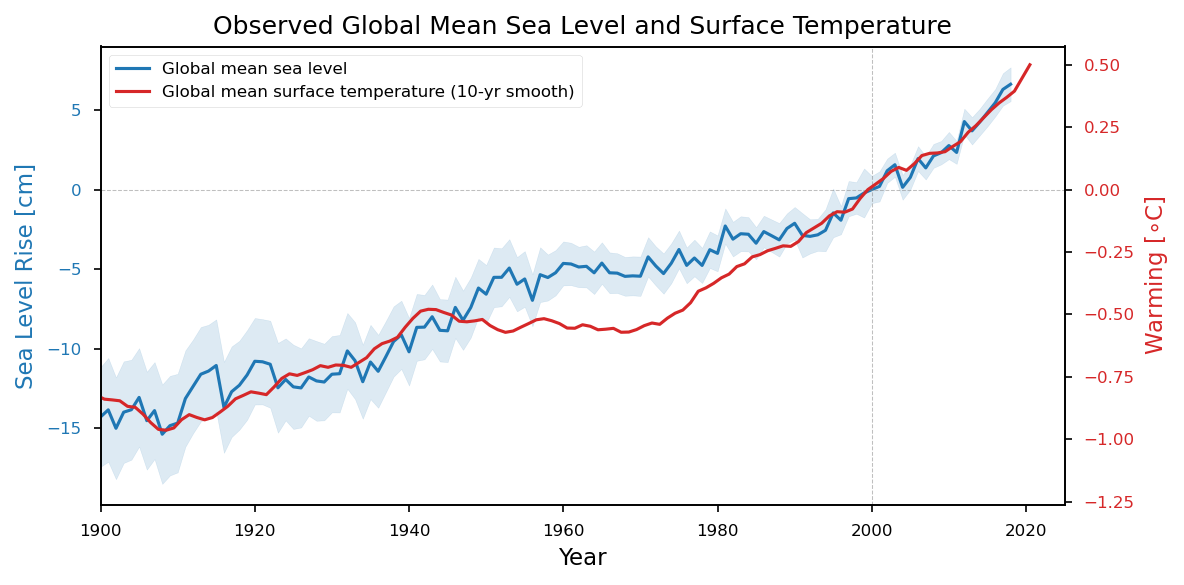

Figure 1 saved.


In [108]:
# ==============================================================
# Figure 1: Frederikse GMSL + Berkeley Earth GMST (20-yr smooth)
# ==============================================================
fig, ax1 = plt.subplots(figsize=(8, 4))

# GMSL on left y-axis
unit_convert = 100.
ax1.plot(fred_time, fred_gmsl_rb*unit_convert, color='tab:blue', linewidth=1.5,
         label='Global mean sea level')

#ax1.plot(horw_time, horw_gmsl_smooth*unit_convert, '-', color='tab:orange', linewidth=1.5)

ax1.fill_between(fred_time,
                 unit_convert*(fred_gmsl_rb - 1.645 * fred_gmsl_sigma),
                 unit_convert*(fred_gmsl_rb + 1.645 * fred_gmsl_sigma),
                 color='tab:blue', alpha=0.15)#, label='90% CI')
ax1.set_xlabel('Year')
ax1.set_ylabel('Sea Level Rise [cm]',
               color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)
ax1.axvline(BASELINE_YEAR,color='gray', ls='--', lw=0.5, alpha=0.5)

# GMST on right y-axis
ax2 = ax1.twinx()
mask_smooth = temp_annual['temp_smooth_rb'].notna()
ax2.plot(temp_annual['year'].values[mask_smooth],
         temp_annual['temp_smooth_rb'].values[mask_smooth],
         color='tab:red', linewidth=1.5, linestyle='-',
         label='Global mean surface temperature (10-yr smooth)')
ax2.set_ylabel(r'Warming [$\circ$C]',
               color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           frameon=True, framealpha=0.9)

# Align y = 0 on both axes to the same horizontal position
sl_lo, sl_hi = ax1.get_ylim()
t_lo, t_hi = ax2.get_ylim()
# Fraction of zero from bottom for each axis
f_sl = -sl_lo / (sl_hi - sl_lo)
f_t  = -t_lo / (t_hi - t_lo)
# Expand the axis whose zero is closer to the bottom
if f_sl > f_t:
    # Push GMST lower limit down so its zero matches GMSL's
    new_t_lo = -f_sl / (1 - f_sl) * t_hi
    ax2.set_ylim(new_t_lo, t_hi)
else:
    # Push GMSL lower limit down so its zero matches GMST's
    new_sl_lo = -f_t / (1 - f_t) * sl_hi
    ax1.set_ylim(new_sl_lo, sl_hi)

ax1.set_xlim(1900, 2025)
ax1.set_title('Observed Global Mean Sea Level and Surface Temperature')
fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig1_observations.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 5. Two-Panel Projection Plot with Societal Impact Axes

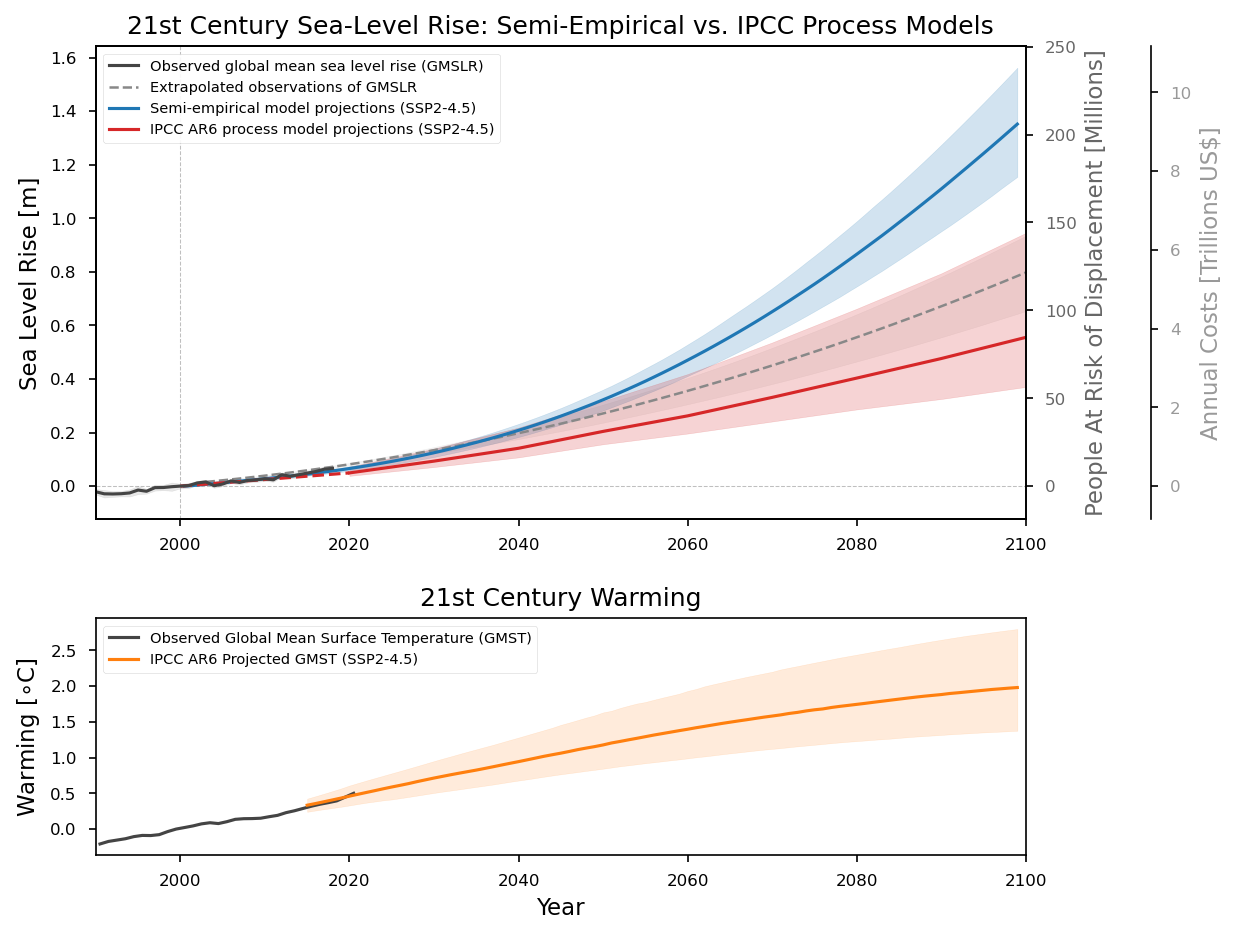

Figure 2 saved.


In [131]:
# ============================================================
# Figure 2: Two-panel projection plot
# Upper: GMSL projections + impact axes
# Lower: GMST observations + IPCC projections
# ============================================================

# --- Ensure kinematics extrapolation variables exist (from cell 8) ---
if 't_end' not in dir():
    EXTRAP_BW = 30
    kin = compute_kinematics(
        time=fred_time, value=fred_gmsl_rb,
        sigma=fred_gmsl_sigma, span_years=EXTRAP_BW,
    )
    rate_end = kin.rate[-1]
    rate_se_end = kin.rate_se[-1]
    accel_end = kin.accel[-1]
    accel_se_end = kin.accel_se[-1]
    t_end = kin.time[-1]
    H_end = fred_gmsl_rb[-1]
    t_extrap = np.arange(fred_time[0], 2101, dtype=float)
    dt_extrap = t_extrap - t_end
    quad_extrap = np.where(
        t_extrap <= t_end,
        np.interp(t_extrap, fred_time, fred_gmsl_rb),
        H_end + rate_end * dt_extrap + 0.5 * accel_end * dt_extrap**2,
    )
    rng = np.random.default_rng(42)
    n_boot = 2000
    quad_boot = np.zeros((n_boot, len(t_extrap)))
    for k in range(n_boot):
        r_k = rng.normal(rate_end, rate_se_end)
        a_k = rng.normal(accel_end, accel_se_end)
        quad_boot[k] = np.where(
            t_extrap <= t_end,
            np.interp(t_extrap, fred_time, fred_gmsl_rb),
            H_end + r_k * dt_extrap + 0.5 * a_k * dt_extrap**2,
        )
    quad_p5 = np.percentile(quad_boot, 5, axis=0)
    quad_p95 = np.percentile(quad_boot, 95, axis=0)
    print(f'[auto-computed kinematics: rate={rate_end*M_TO_MM:.2f} mm/yr, '
          f'accel={accel_end*M_TO_MM:.4f} mm/yr²]')

# --- User-adjustable parameters ---
YEAR_START = 1990
YEAR_END = 2100
SSP = 'SSP2-4.5'
COLOR_OBS = '#444444'          # dark grey for observations
COLOR_EXTRAP = '#888888'       # lighter grey for extrapolation
COLOR_RS = 'tab:blue'          # Rate-and-state model
COLOR_IPCC = 'tab:red'         # IPCC process models
COLOR_GMST = 'tab:orange'      # GMST
ALPHA_CI = 0.2

fig = plt.figure(figsize=(8, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.28)

# ==================== UPPER PANEL: GMSL ====================
ax_sl = fig.add_subplot(gs[0])

ax_sl.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)
ax_sl.axvline(BASELINE_YEAR,color='gray', ls='--', lw=0.5, alpha=0.5)

# Frederikse observations
mask_obs = (fred_time >= YEAR_START) & (fred_time <= YEAR_END)
ax_sl.plot(fred_time[mask_obs], fred_gmsl_rb[mask_obs],
           color=COLOR_OBS, linewidth=1.5, label='Observed global mean sea level rise (GMSLR)', zorder=10)
ax_sl.fill_between(fred_time[mask_obs],
                   fred_gmsl_rb[mask_obs] - 1.645 * fred_gmsl_sigma[mask_obs],
                   fred_gmsl_rb[mask_obs] + 1.645 * fred_gmsl_sigma[mask_obs],
                   color=COLOR_OBS, alpha=0.12)

# Kinematics extrapolation (dashed, beyond end of data only)
mask_ext = (t_extrap >= t_end) & (t_extrap <= YEAR_END)
ax_sl.plot(t_extrap[mask_ext], quad_extrap[mask_ext],
           color=COLOR_EXTRAP, linewidth=1.2, linestyle='--',
           label='Extrapolated observations of GMSLR')
ax_sl.fill_between(t_extrap[mask_ext], quad_p5[mask_ext], quad_p95[mask_ext],
                   color=COLOR_EXTRAP, alpha=0.1)

# Rate-and-state posterior mean projection
rs_df = mc_results['scenarios'][SSP]
rs_time = rs_df['decimal_year'].values
mask_rs = (rs_time >= YEAR_START) & (rs_time <= YEAR_END)
ax_sl.plot(rs_time[mask_rs], rs_df['gmsl'].values[mask_rs],
           color=COLOR_RS, linewidth=1.5,
           label=f'Semi-empirical model projections ({SSP})')
ax_sl.fill_between(rs_time[mask_rs],
                   rs_df['gmsl_lower'].values[mask_rs],
                   rs_df['gmsl_upper'].values[mask_rs],
                   color=COLOR_RS, alpha=ALPHA_CI)

# IPCC process-model projection
ipcc_df = ipcc_gmsl_rb[SSP]
ipcc_time = ipcc_df['decimal_year'].values
mask_ipcc = (ipcc_time >= YEAR_START) & (ipcc_time <= 2100)
ax_sl.plot(ipcc_time[mask_ipcc], ipcc_df['gmsl'].values[mask_ipcc],
           color=COLOR_IPCC, linewidth=1.5,
           label=f'IPCC AR6 process model projections ({SSP})')
ax_sl.fill_between(ipcc_time[mask_ipcc],
                   ipcc_df['gmsl_lower'].values[mask_ipcc],
                   ipcc_df['gmsl_upper'].values[mask_ipcc],
                   color=COLOR_IPCC, alpha=ALPHA_CI)

# IPCC hindcast: dashed line from baseline (year 2000, 0) to first projection point
ax_sl.plot([2000, ipcc_time[mask_ipcc][0]],
           [0.0, ipcc_df['gmsl'].values[mask_ipcc][0]],
           color=COLOR_IPCC, linewidth=1.5, linestyle='--')

ax_sl.set_xlim(YEAR_START, YEAR_END)
ax_sl.set_ylabel('Sea Level Rise [m]')
ax_sl.legend(loc='upper left', fontsize=7, frameon=True, framealpha=0.9)
ax_sl.set_title(f'21st Century Sea-Level Rise: Semi-Empirical vs. IPCC Process Models')


# --- Right axis 1: Additional people exposed (elevation only, no defenses) (from Kulp & Strauss 2019) ---
# Linear scaling baselined to zero at SLR = 0 (baseline year),
# so impact axes read 0 at the baseline regardless of YEAR_START.
pop_baseline = people_displaced_kulpstrauss2019(0.0)
ax_pop = ax_sl.twinx()
sl_lo, sl_hi = ax_sl.get_ylim()
pop_at_hi = people_displaced_kulpstrauss2019(sl_hi) - pop_baseline
pop_scale = pop_at_hi / sl_hi if sl_hi > 0 else 0
ax_pop.set_ylim(pop_scale * sl_lo, pop_scale * sl_hi)
ax_pop.set_ylabel("People At Risk of Displacement [Millions]", color="#666666")
ax_pop.tick_params(axis='y', labelcolor='#666666')
ax_pop.spines['right'].set_position(('outward', 0))

# --- Right axis 2: Annual flood cost (from Jevrejeva 2018) ---
ax_cost = ax_sl.twinx()
ax_cost.spines['right'].set_position(('outward', 60))
cost_at_hi = 0.45e-3 * slr_cost_jevrejeva2018(sl_hi)
cost_scale = cost_at_hi / sl_hi if sl_hi > 0 else 0
ax_cost.set_ylim(cost_scale * sl_lo, cost_scale * sl_hi)
ax_cost.set_ylabel('Annual Costs [Trillions US\\$]', color='#999999')
ax_cost.tick_params(axis='y', labelcolor='#999999')

# ==================== LOWER PANEL: GMST ====================
ax_t = fig.add_subplot(gs[1], sharex=ax_sl)

# Observed 20-yr smoothed GMST
mask_ts = (temp_annual['year'].values >= YEAR_START) & \
          (temp_annual['year'].values <= YEAR_END) & \
          temp_annual['temp_smooth_rb'].notna()
ax_t.plot(temp_annual['year'].values[mask_ts],
          temp_annual['temp_smooth_rb'].values[mask_ts],
          color=COLOR_OBS, linewidth=1.5,
          label='Observed Global Mean Surface Temperature (GMST)')

# IPCC SSP temperature projection
tp_df = temp_proj_rb[SSP]
tp_time = tp_df['decimal_year'].values
mask_tp = (tp_time >= YEAR_START) & (tp_time <= YEAR_END)
ax_t.plot(tp_time[mask_tp], tp_df['temperature'].values[mask_tp],
          color=COLOR_GMST, linewidth=1.5, linestyle='-',
          label=f'IPCC AR6 Projected GMST ({SSP})')
if 'temperature_lower' in tp_df.columns:
    ax_t.fill_between(tp_time[mask_tp],
                      tp_df['temperature_lower'].values[mask_tp],
                      tp_df['temperature_upper'].values[mask_tp],
                      color=COLOR_GMST, alpha=0.15)

ax_t.set_title(f"21st Century Warming")
ax_t.set_xlabel('Year')
ax_t.set_ylabel(r'Warming [$\circ$C]')
ax_t.legend(loc='upper left', fontsize=7, frameon=True, framealpha=0.9)

fig.savefig('../figures/stats_v_process_fig2_projections.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 6. Hindcast Cross-Validation

In [68]:
# ============================================================
# Hindcast: calibrate on truncated records, project forward
# using observed Berkeley Earth temperatures (not SSPs)
# ============================================================

HINDCAST_START_YEAR = 1920
CUTOFF_YEARS = [2000, 2010, 2018]
HINDCAST_COLORS = {2000: 'tab:green', 2010: 'tab:purple', 2018: 'tab:orange'}
PLOT_YEAR_START = 1975
PLOT_YEAR_END = 2100

# --- Bayesian level-space priors (matching bayesian_ratestate.ipynb) ---
PRIOR_SCALE_A = 0.005 / np.log(10)    # ~0.00217 m/yr/°C²; P(a > 5 mm/yr/°C²) = 10%
PRIOR_SCALE_B = 0.010                  # HalfNormal sigma for b
PRIOR_C_MEAN  = 0.002                  # Normal mean for c (trend)
PRIOR_C_SIGMA = 0.005                  # Normal sigma for c
PRIOR_SIGMA_EXTRA_SCALE = 0.005        # HalfCauchy(5 mm)
PRIOR_H0_SIGMA = 0.050                # Normal sigma for H₀ (50 mm)

# Observed temperature for forward projection — use calibration
# baseline (1995-2005), NOT year-2000 rebase, to be consistent
# with DOLS coefficients
temp_for_proj = temp_annual[['temperature']].copy()
temp_for_proj['decimal_year'] = temp_annual['year'].values

# Build observed + SSP2-4.5 temperature for projection beyond obs
# Shift IPCC from pre-industrial to Berkeley Earth 1995-2005 baseline
tp_ssp_cal = temp_projections[SSP].copy()
ipcc_fy = tp_ssp_cal['decimal_year'].iloc[0]
idx_ov = np.argmin(np.abs(temp_annual['year'].values - ipcc_fy))
cal_off = tp_ssp_cal['temperature'].iloc[0] - temp_annual['temperature'].iloc[idx_ov]
tp_ssp_cal['temperature'] = tp_ssp_cal['temperature'] - cal_off

temp_proj_combined = pd.concat([
    temp_for_proj[temp_for_proj['decimal_year'] < tp_ssp_cal['decimal_year'].iloc[0]],
    tp_ssp_cal[['temperature', 'decimal_year']]
], ignore_index=True)
temp_proj_combined.index = pd.to_datetime(
    temp_proj_combined['decimal_year'].astype(int).astype(str) + '-01-01'
)

hindcast_results = {}

for cut_yr in CUTOFF_YEARS:
    # --- Truncate calibration data to <= cut_yr ---
    obs_mask_cal = fred_time <= cut_yr
    obs_years_cal = fred_time[obs_mask_cal]
    H_obs_cal = fred_gmsl[obs_mask_cal]            # native baseline (meters)
    sigma_cal = fred_gmsl_sigma[obs_mask_cal]

    if len(obs_years_cal) < 50:
        print(f'Skipping cutoff {cut_yr}: insufficient data')
        continue

    # --- Monthly temperature for calibration period ---
    mask_monthly = ((time_monthly_all >= obs_years_cal[0]) &
                    (time_monthly_all <= obs_years_cal[-1] + 0.99))
    T_monthly_cal = T_monthly_all[mask_monthly]
    time_monthly_cal = time_monthly_all[mask_monthly]

    # --- Build design vectors ---
    dv = build_level_design_vectors(
        temperature_monthly=T_monthly_cal,
        time_monthly=time_monthly_cal,
        obs_times=obs_years_cal,
    )

    # --- Fit Bayesian level-space model ---
    try:
        result_trunc = fit_bayesian_level(
            H_obs=H_obs_cal,
            sigma_obs=sigma_cal,
            I2_obs=dv['I2_obs'],
            I1_obs=dv['I1_obs'],
            I0_obs=dv['I0_obs'],
            prior_scale_a=PRIOR_SCALE_A,
            prior_scale_b=PRIOR_SCALE_B,
            prior_c_mean=PRIOR_C_MEAN,
            prior_c_sigma=PRIOR_C_SIGMA,
            prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
            prior_H0_sigma=PRIOR_H0_SIGMA,
            n_samples=2000,
            n_walkers=32,
            n_burnin=1000,
            progress=False,
            seed=42,
        )
    except Exception as e:
        print(f'Calibration failed for cutoff {cut_yr}: {e}')
        continue

    coeffs_trunc = result_trunc.physical_coefficients
    cov_trunc = result_trunc.physical_covariance

    # Project with observed + SSP temperatures (calibration baseline)
    mc_hind = project_gmsl_ensemble(
        coefficients=coeffs_trunc,
        coefficients_cov=cov_trunc,
        temperature_projections={'projection': temp_proj_combined},
        baseline_year=BASELINE_YEAR,
        baseline_gmsl=0.0,
        n_samples=N_SAMPLES,
        seed=42,
    )
    hind_df = mc_hind['scenarios']['projection']

    # Compute verification statistics against held-out obs
    obs_mask = (fred_time > cut_yr) & (fred_time <= fred_time[-1])
    if obs_mask.sum() > 0:
        hind_time = hind_df['decimal_year'].values
        pred_at_obs = np.interp(fred_time[obs_mask], hind_time,
                                hind_df['gmsl'].values)
        pred_lo = np.interp(fred_time[obs_mask], hind_time,
                            hind_df['gmsl_lower'].values)
        pred_hi = np.interp(fred_time[obs_mask], hind_time,
                            hind_df['gmsl_upper'].values)
        resid = fred_gmsl_rb[obs_mask] - pred_at_obs
        rmse = np.sqrt(np.mean(resid**2)) * M_TO_MM
        bias = np.mean(resid) * M_TO_MM
        coverage = np.mean(
            (fred_gmsl_rb[obs_mask] >= pred_lo) &
            (fred_gmsl_rb[obs_mask] <= pred_hi)
        )
    else:
        rmse, bias, coverage = np.nan, np.nan, np.nan

    hindcast_results[cut_yr] = {
        'result': result_trunc,
        'projection': hind_df,
        'rmse_mm': rmse,
        'bias_mm': bias,
        'coverage_90': coverage,
    }

    print(f'Cutoff {cut_yr}: '
          f'dα/dT={coeffs_trunc[0]*M_TO_MM:.3f}, '
          f'α₀={coeffs_trunc[1]*M_TO_MM:.3f}, '
          f'trend={coeffs_trunc[2]*M_TO_MM:.3f}  |  '
          f'RMSE={rmse:.1f} mm, Bias={bias:.1f} mm, '
          f'90% Coverage={coverage:.0%}')

Cutoff 2000: dα/dT=1.806, α₀=1.634, trend=1.622  |  RMSE=15.5 mm, Bias=11.3 mm, 90% Coverage=22%
Cutoff 2010: dα/dT=3.535, α₀=3.996, trend=2.336  |  RMSE=8.6 mm, Bias=5.8 mm, 90% Coverage=38%
Cutoff 2018: dα/dT=4.820, α₀=5.209, trend=2.532  |  RMSE=nan mm, Bias=nan mm, 90% Coverage=nan%


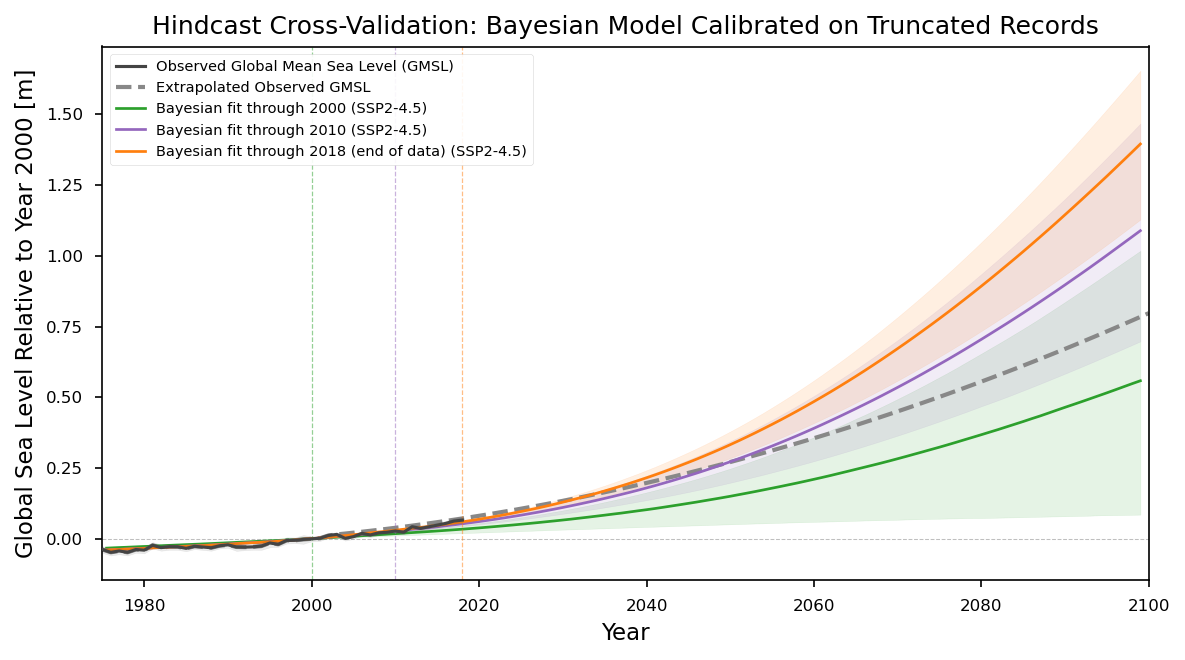

Figure 3 saved.


In [119]:
# ============================================================
# Figure 3: Hindcast cross-validation
# ============================================================

# --- Ensure kinematics extrapolation variables exist (from cell 8) ---
if 't_end' not in dir():
    EXTRAP_BW = 30
    kin = compute_kinematics(
        time=fred_time, value=fred_gmsl_rb,
        sigma=fred_gmsl_sigma, span_years=EXTRAP_BW,
    )
    rate_end, accel_end = kin.rate[-1], kin.accel[-1]
    rate_se_end, accel_se_end = kin.rate_se[-1], kin.accel_se[-1]
    t_end, H_end = kin.time[-1], fred_gmsl_rb[-1]
    t_extrap = np.arange(fred_time[0], 2101, dtype=float)
    dt_extrap = t_extrap - t_end
    quad_extrap = np.where(
        t_extrap <= t_end,
        np.interp(t_extrap, fred_time, fred_gmsl_rb),
        H_end + rate_end * dt_extrap + 0.5 * accel_end * dt_extrap**2,
    )

# Ensure color constants exist (from cell 12)
COLOR_OBS = COLOR_OBS if 'COLOR_OBS' in dir() else '#444444'
COLOR_EXTRAP = COLOR_EXTRAP if 'COLOR_EXTRAP' in dir() else '#888888'
SSP = SSP if 'SSP' in dir() else 'SSP2-4.5'

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)

# Observations
mask_plot = (fred_time >= PLOT_YEAR_START) & (fred_time <= PLOT_YEAR_END)
ax.plot(fred_time[mask_plot], fred_gmsl_rb[mask_plot],
        color=COLOR_OBS, linewidth=1.5, zorder=5,
        label='Observed Global Mean Sea Level (GMSL)')
ax.fill_between(fred_time[mask_plot],
                fred_gmsl_rb[mask_plot] - 1.645 * fred_gmsl_sigma[mask_plot],
                fred_gmsl_rb[mask_plot] + 1.645 * fred_gmsl_sigma[mask_plot],
                color=COLOR_OBS, alpha=0.1, zorder=4)

# Kinematics extrapolation
mask_ext2 = (t_extrap >= PLOT_YEAR_START) & (t_extrap <= PLOT_YEAR_END)
ax.plot(t_extrap[mask_ext2], quad_extrap[mask_ext2],
        color=COLOR_EXTRAP, linewidth=2, linestyle='--',
        label='Extrapolated Observed GMSL')

# Hindcast projections
for cut_yr, hr in hindcast_results.items():
    hdf = hr['projection']
    ht = hdf['decimal_year'].values
    mask_h = (ht >= PLOT_YEAR_START) & (ht <= PLOT_YEAR_END)

    color = HINDCAST_COLORS[cut_yr]
    label_end = f' (end of data)' if cut_yr >= fred_time[-1] else ''
    ax.plot(ht[mask_h], hdf['gmsl'].values[mask_h],
            color=color, linewidth=1.3,
            label=f'Bayesian fit through {cut_yr}{label_end} ({SSP})')
    ax.fill_between(ht[mask_h],
                    hdf['gmsl_lower'].values[mask_h],
                    hdf['gmsl_upper'].values[mask_h],
                    color=color, alpha=0.12)

    # Mark the cutoff year
    cut_idx = np.argmin(np.abs(fred_time - cut_yr))
    if cut_idx < len(fred_gmsl_rb):
        ax.axvline(cut_yr, color=color, linewidth=0.6, linestyle='--',
                   alpha=0.5)

ax.set_xlim(PLOT_YEAR_START, PLOT_YEAR_END)
ax.set_xlabel('Year')
ax.set_ylabel('Global Sea Level Relative to Year 2000 [m]')
ax.set_title('Hindcast Cross-Validation: Bayesian Model Calibrated on Truncated Records')
ax.legend(loc='upper left', fontsize=7, frameon=True, framealpha=0.9)

fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig3_hindcast.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

Component catalog: 224 files total
Files for ssp245:
component_type    version      model           
glaciers          ar5          glaciersgmip2       1
                  ipccar6      gmipemuglaciers     1
icesheets         FittedISMIP  icesheets           1
                  ar5          icesheets           4
                  dp20         icesheet            3
                  ipccar6      bambericesheet      4
                               ismipemuicesheet    5
                               larmipicesheet      6
landwaterstorage  ssp          landwaterstorage    1
oceandynamics     tlm          oceandynamics       1

Loaded 27 component DataFrames for ssp245
  glaciers-ar5-glaciersgmip2-ssp245: 20000 samples × 29 years, median@2100 = 121 m×1000
  glaciers-ipccar6-gmipemuglaciers-ssp245: 20000 samples × 9 years, median@2100 = 123 m×1000
  icesheets-FittedISMIP-icesheets-ssp245_GIS: 20000 samples × 29 years, median@2100 = 103 m×1000
  icesheets-ar5-icesheets-ssp245_AIS: 20000 samp

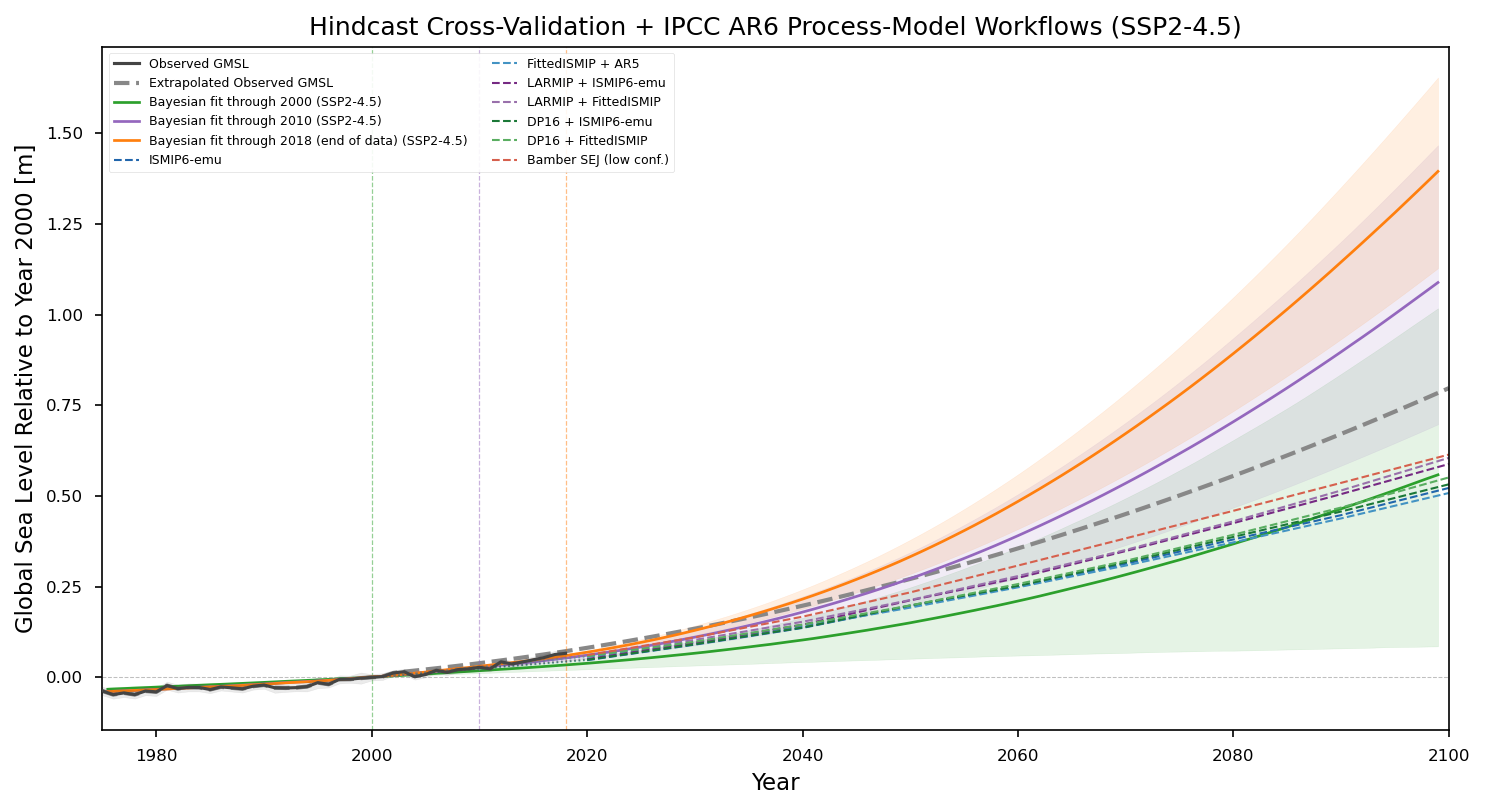

Figure 4 saved.


In [129]:
# ============================================================
# Figure 4: Hindcast cross-validation + IPCC AR6 process-model
#           workflow ensembles
# ============================================================
# Shows individual FACTS workflow total GMSL projections alongside
# the hindcast cross-validation and kinematic extrapolation.
# Each workflow combines different ice-sheet, glacier, ocean
# dynamics, and land water storage models.
#
# Component data lives in full_sample_components/ (224 files);
# the workflow totals in full_sample_workflows/ properly sum
# the matched components with preserved sample correlations.

from slr_ar6_member_readers import (
    read_ar6_workflow_totals,
    list_ar6_full_sample_components,
    read_ar6_full_sample_components,
    WORKFLOW_INFO,
)

# --- Ensure kinematics extrapolation variables exist (from cell 8) ---
if 't_end' not in dir():
    EXTRAP_BW = 30
    kin = compute_kinematics(
        time=fred_time, value=fred_gmsl_rb,
        sigma=fred_gmsl_sigma, span_years=EXTRAP_BW,
    )
    rate_end, accel_end = kin.rate[-1], kin.accel[-1]
    rate_se_end, accel_se_end = kin.rate_se[-1], kin.accel_se[-1]
    t_end, H_end = kin.time[-1], fred_gmsl_rb[-1]
    t_extrap = np.arange(fred_time[0], 2101, dtype=float)
    dt_extrap = t_extrap - t_end
    quad_extrap = np.where(
        t_extrap <= t_end,
        np.interp(t_extrap, fred_time, fred_gmsl_rb),
        H_end + rate_end * dt_extrap + 0.5 * accel_end * dt_extrap**2,
    )

# Ensure color constants exist (from cell 12)
COLOR_OBS = COLOR_OBS if 'COLOR_OBS' in dir() else '#444444'
COLOR_EXTRAP = COLOR_EXTRAP if 'COLOR_EXTRAP' in dir() else '#888888'
SSP = SSP if 'SSP' in dir() else 'SSP2-4.5'

# ============================================================
# Load component catalog (all 224 files — metadata only)
# ============================================================
comp_dir = '../data/raw/ipcc_ar6/slr/ar6/global/full_sample_components'
catalog = list_ar6_full_sample_components(comp_dir)
ssp_code = ssp_gmsl_keys[SSP]

print(f'Component catalog: {len(catalog)} files total')
print(f'Files for {ssp_code}:')
cat_ssp = catalog[catalog['scenario'] == ssp_code]
print(cat_ssp.groupby(['component_type', 'version', 'model']).size().to_string())

# ============================================================
# Load all component data for selected SSP (full 20k samples)
# ============================================================
comp_data = read_ar6_full_sample_components(comp_dir, scenario=ssp_code)
print(f'\nLoaded {len(comp_data)} component DataFrames for {ssp_code}')
for key, df in sorted(comp_data.items()):
    med_2100 = df[2100].median() * M_TO_MM if 2100 in df.columns else float('nan')
    print(f'  {key}: {df.shape[0]} samples × {df.shape[1]} years, '
          f'median@2100 = {med_2100:.0f} {df.attrs["current_units"]}×1000')

# ============================================================
# Load workflow totals for the selected SSP
# ============================================================
wf_dir = '../data/raw/ipcc_ar6/slr/ar6/global/full_sample_workflows'
wf_totals = read_ar6_workflow_totals(wf_dir, scenario=ssp_code)

# Rebase all workflows to year 2000 = 0 (same as Frederikse)
for key in wf_totals:
    wf_totals[key] = wf_totals[key] - fred_gmsl_2000

print(f'\nWorkflow totals for {SSP} ({ssp_code}), rebased to yr 2000:')
for key, df in sorted(wf_totals.items()):
    wf_name = key.split('/')[0]
    info = WORKFLOW_INFO.get(wf_name, {})
    med = df[2100].median() * M_TO_MM if 2100 in df.columns else float('nan')
    p5 = df[2100].quantile(0.05) * M_TO_MM if 2100 in df.columns else float('nan')
    p95 = df[2100].quantile(0.95) * M_TO_MM if 2100 in df.columns else float('nan')
    print(f'  {key} ({info.get("label","?")}, {info.get("confidence","?")}): '
          f'median@2100 = {med:.0f} mm [{p5:.0f}–{p95:.0f}]')

# ============================================================
# Compute per-workflow percentile statistics (years ≤ 2100)
# ============================================================
wf_stats = {}
for key, df in sorted(wf_totals.items()):
    years = np.array([y for y in df.columns if y <= 2100])
    df_cut = df[years]
    wf_stats[key] = {
        'years': years,
        'median': df_cut.median(axis=0).values,
        'p5': df_cut.quantile(0.05, axis=0).values,
        'p95': df_cut.quantile(0.95, axis=0).values,
    }

# ============================================================
# Plot
# ============================================================
WF_COLORS = {
    'wf_1e': '#2166ac',   # blue
    'wf_1f': '#4393c3',   # light blue
    'wf_2e': '#762a83',   # purple
    'wf_2f': '#9970ab',   # light purple
    'wf_3e': '#1b7837',   # green
    'wf_3f': '#5aae61',   # light green
    'wf_4':  '#d6604d',   # red (low confidence)
}

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)

# --- Observations ---
mask_plot = (fred_time >= PLOT_YEAR_START) & (fred_time <= PLOT_YEAR_END)
ax.plot(fred_time[mask_plot], fred_gmsl_rb[mask_plot],
        color=COLOR_OBS, linewidth=1.5, zorder=10,
        label='Observed GMSL')
ax.fill_between(fred_time[mask_plot],
                fred_gmsl_rb[mask_plot] - 1.645 * fred_gmsl_sigma[mask_plot],
                fred_gmsl_rb[mask_plot] + 1.645 * fred_gmsl_sigma[mask_plot],
                color=COLOR_OBS, alpha=0.1, zorder=9)

#ax.plot(nasa_time, nasa_gmsl,color='tab:red',lw=1.5,zorder=20)

# --- Kinematics extrapolation ---
mask_ext2 = (t_extrap >= PLOT_YEAR_START) & (t_extrap <= PLOT_YEAR_END)
ax.plot(t_extrap[mask_ext2], quad_extrap[mask_ext2],
        color=COLOR_EXTRAP, linewidth=2, linestyle='--',
        label='Extrapolated Observed GMSL')

#ne = nasa_extrap                       # shorthand
#mask_ext = (ne['time'] >= FIG5_YEAR_START) & (ne['time'] <= 2100)
#ax.plot(ne['time'][mask_ext], ne['gmsl'][mask_ext],
#        color='#444444', linewidth=2, linestyle='--', zorder=10,
#        label=f'Mid-record extrapolation ({ne["t_mid"]:.0f})')

# --- Hindcast projections ---
for cut_yr, hr in hindcast_results.items():
    hdf = hr['projection']
    ht = hdf['decimal_year'].values
    mask_h = (ht >= PLOT_YEAR_START) & (ht <= PLOT_YEAR_END)

    color = HINDCAST_COLORS[cut_yr]
    label_end = f' (end of data)' if cut_yr >= fred_time[-1] else ''
    ax.plot(ht[mask_h], hdf['gmsl'].values[mask_h],
            color=color, linewidth=1.3,
            label=f'Bayesian fit through {cut_yr}{label_end} ({SSP})')
    ax.fill_between(ht[mask_h],
                    hdf['gmsl_lower'].values[mask_h],
                    hdf['gmsl_upper'].values[mask_h],
                    color=color, alpha=0.12)

    cut_idx = np.argmin(np.abs(fred_time - cut_yr))
    if cut_idx < len(fred_gmsl_rb):
        ax.axvline(cut_yr, color=color, linewidth=0.6, linestyle='--',
                   alpha=0.5)

# --- IPCC AR6 workflow ensembles ---
for key, stats in wf_stats.items():
    wf_name = key.split('/')[0]
    info = WORKFLOW_INFO.get(wf_name, {})
    color = WF_COLORS.get(wf_name, 'tab:gray')
    label = info.get('label', wf_name)
    conf = info.get('confidence', '')
    if conf == 'low':
        label += ' (low conf.)'

    years = stats['years']
    mask_wf = (years >= PLOT_YEAR_START) & (years <= PLOT_YEAR_END)

    # Dashed bridge from baseline (yr 2000, 0) to first projection point
    ax.plot([2000, years[mask_wf][0]],
            [0.0, stats['median'][mask_wf][0]],
            color=color, linewidth=0.8, linestyle=':', alpha=0.5)

    ax.plot(years[mask_wf], stats['median'][mask_wf],
            color=color, linewidth=1.0, linestyle='--',
            label=label)
    #ax.fill_between(years[mask_wf],
    #                stats['p5'][mask_wf], stats['p95'][mask_wf],
    #                color=color, alpha=0.06)

ax.set_xlim(PLOT_YEAR_START, PLOT_YEAR_END)
ax.set_xlabel('Year')
ax.set_ylabel('Global Sea Level Relative to Year 2000 [m]')
ax.set_title(f'Hindcast Cross-Validation + IPCC AR6 Process-Model Workflows ({SSP})')
ax.legend(loc='upper left', fontsize=6, frameon=True, framealpha=0.9, ncol=2)

fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig4_hindcast_ismip6.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

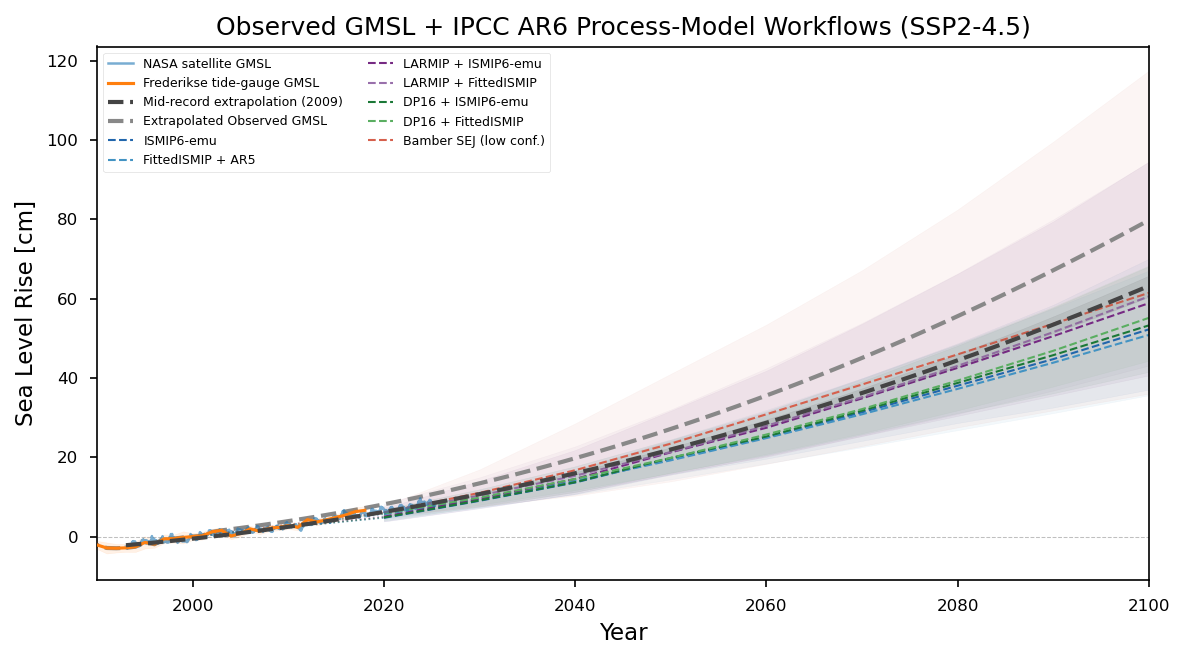

Figure 5 saved.


In [128]:
# ============================================================
# Figure 5: NASA satellite GMSL + mid-record kinematic
#           extrapolation + IPCC AR6 workflow ensembles
# ============================================================
# nasa_extrap dict computed in cell 8; wf_stats computed in cell 16.

from slr_ar6_member_readers import WORKFLOW_INFO

FIG5_YEAR_START = 1990
FIG5_YEAR_END   = 2100

WF_COLORS = {
    'wf_1e': '#2166ac',   'wf_1f': '#4393c3',
    'wf_2e': '#762a83',   'wf_2f': '#9970ab',
    'wf_3e': '#1b7837',   'wf_3f': '#5aae61',
    'wf_4':  '#d6604d',
}
unit_convert = 100.   # meters → cm for display

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)

# --- NASA satellite GMSL ---
mask_nasa = (nasa_time >= FIG5_YEAR_START) & (nasa_time <= FIG5_YEAR_END)
ax.plot(nasa_time[mask_nasa], nasa_gmsl_rb[mask_nasa] * unit_convert,
        color='tab:blue', linewidth=1.2, alpha=0.6, zorder=8,
        label='NASA satellite GMSL')

plot_fred = True
if plot_fred:
    # --- Frederikse tide-gauge GMSL (for context) ---
    mask_fred = (fred_time >= FIG5_YEAR_START) & (fred_time <= fred_time[-1])
    ax.plot(fred_time[mask_fred], fred_gmsl_rb[mask_fred] * unit_convert,
            color='tab:orange', linewidth=1.5, zorder=9,
            label='Frederikse tide-gauge GMSL')
    ax.fill_between(fred_time[mask_fred],
                    (fred_gmsl_rb[mask_fred] - 1.645 * fred_gmsl_sigma[mask_fred]) * unit_convert,
                    (fred_gmsl_rb[mask_fred] + 1.645 * fred_gmsl_sigma[mask_fred]) * unit_convert,
                    color='tab:orange', alpha=0.1, zorder=7)

# --- Mid-record kinematic extrapolation (from nasa_extrap) ---
ne = nasa_extrap                       # shorthand
mask_ext = (ne['time'] >= FIG5_YEAR_START) & (ne['time'] <= FIG5_YEAR_END)
ax.plot(ne['time'][mask_ext], ne['gmsl'][mask_ext] * unit_convert,
        color='#444444', linewidth=2, linestyle='--', zorder=10,
        label=f'Mid-record extrapolation ({ne["t_mid"]:.0f})')
ax.fill_between(ne['time'][mask_ext],
                ne['p5'][mask_ext] * unit_convert,
                ne['p95'][mask_ext] * unit_convert,
                color='#444444', alpha=0.10, zorder=6)

mask_ext2 = (t_extrap >= PLOT_YEAR_START) & (t_extrap <= PLOT_YEAR_END)
ax.plot(t_extrap[mask_ext2], 100.*quad_extrap[mask_ext2],
        color=COLOR_EXTRAP, linewidth=2, linestyle='--',
        label='Extrapolated Observed GMSL')

# Mark mid-record anchor point
#ax.plot(ne['t_mid'], ne['H_mid'] * unit_convert,
#        'o', color='#444444', markersize=5, zorder=11)

# --- IPCC AR6 workflow ensembles ---
for key, stats in wf_stats.items():
    wf_name = key.split('/')[0]
    info = WORKFLOW_INFO.get(wf_name, {})
    color = WF_COLORS.get(wf_name, 'tab:gray')
    label = info.get('label', wf_name)
    conf = info.get('confidence', '')
    if conf == 'low':
        label += ' (low conf.)'

    years = stats['years']
    mask_wf = (years >= FIG5_YEAR_START) & (years <= FIG5_YEAR_END)
    if mask_wf.sum() == 0:
        continue

    # Bridge from year 2000 to first projection point
    ax.plot([BASELINE_YEAR, years[mask_wf][0]],
            [0.0, stats['median'][mask_wf][0] * unit_convert],
            color=color, linewidth=0.8, linestyle=':', alpha=0.5)

    ax.plot(years[mask_wf], stats['median'][mask_wf] * unit_convert,
            color=color, linewidth=1.0, linestyle='--',
            label=label)
    ax.fill_between(years[mask_wf],
                    stats['p5'][mask_wf] * unit_convert,
                    stats['p95'][mask_wf] * unit_convert,
                    color=color, alpha=0.06)

ax.set_xlim(FIG5_YEAR_START, FIG5_YEAR_END)
ax.set_xlabel('Year')
ax.set_ylabel('Sea Level Rise [cm]')
ax.set_title(f'Observed GMSL + IPCC AR6 Process-Model Workflows ({SSP})')
ax.legend(loc='upper left', fontsize=6, frameon=True, framealpha=0.9, ncol=2)

fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig5_gmsl_observations_ipccar6members.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

In [73]:
# ============================================================
# Summary statistics table
# ============================================================
print('\n' + '='*70)
print('HINDCAST CROSS-VALIDATION SUMMARY')
print('='*70)
print(f'{"Cutoff":>8} {"RMSE (mm)":>12} {"Bias (mm)":>12} {"90% Coverage":>14}')
print('-'*50)
for cut_yr, hr in hindcast_results.items():
    print(f'{cut_yr:>8} {hr["rmse_mm"]:>12.1f} {hr["bias_mm"]:>12.1f} '
          f'{hr["coverage_90"]:>13.0%}')

print('\n' + '='*70)
print('PROJECTION COMPARISON AT 2050, 2070, AND 2100')
print('='*70)
rs_df = mc_results['scenarios'][SSP]
ipcc_df = ipcc_gmsl_rb[SSP]
for yr in [2050, 2070, 2100]:
    # Rate-and-state
    idx_r = np.argmin(np.abs(rs_df['decimal_year'].values - yr))
    r_med = rs_df['gmsl'].values[idx_r] * M_TO_MM
    r_lo = rs_df['gmsl_lower'].values[idx_r] * M_TO_MM
    r_hi = rs_df['gmsl_upper'].values[idx_r] * M_TO_MM
    # IPCC
    idx_i = np.argmin(np.abs(ipcc_df['decimal_year'].values - yr))
    i_med = ipcc_df['gmsl'].values[idx_i] * M_TO_MM
    i_lo = ipcc_df['gmsl_lower'].values[idx_i] * M_TO_MM
    i_hi = ipcc_df['gmsl_upper'].values[idx_i] * M_TO_MM
    print(f'\n{yr} ({SSP}):')
    print(f'  Rate-and-state:  {r_med:.0f} mm [{r_lo:.0f}–{r_hi:.0f}] (90% CI)')
    print(f'  IPCC:            {i_med:.0f} mm [{i_lo:.0f}–{i_hi:.0f}] (90% CI)')
    print(f'  Difference:      {r_med - i_med:+.0f} mm (Rate-and-state − IPCC)')


HINDCAST CROSS-VALIDATION SUMMARY
  Cutoff    RMSE (mm)    Bias (mm)   90% Coverage
--------------------------------------------------
    2000         15.5         11.3           22%
    2010          8.6          5.8           38%
    2018          nan          nan          nan%

PROJECTION COMPARISON AT 2050, 2070, AND 2100

2050 (SSP2-4.5):
  Rate-and-state:  322 mm [282–360] (90% CI)
  IPCC:            204 mm [156–317] (90% CI)
  Difference:      +118 mm (Rate-and-state − IPCC)

2070 (SSP2-4.5):
  Rate-and-state:  651 mm [566–739] (90% CI)
  IPCC:            331 mm [241–536] (90% CI)
  Difference:      +320 mm (Rate-and-state − IPCC)

2100 (SSP2-4.5):
  Rate-and-state:  1351 mm [1155–1562] (90% CI)
  IPCC:            555 mm [370–945] (90% CI)
  Difference:      +796 mm (Rate-and-state − IPCC)


## 7. Forecasting Skill Analysis

Three complementary approaches to evaluate IPCC AR6 process-model forecasting skill,
compared against the semi-empirical rate-and-state model:

1. **Direct out-of-sample verification** — bias, RMSE, and 90% CI coverage over 2006–2024
2. **Reliability analysis** — PIT histograms and coverage at multiple confidence levels
3. **Conditional skill** — predictions conditioned on realized (observed) temperature


In [143]:
# ============================================================
# Forecasting skill: data preparation
# ============================================================
# Prepare common data structures for three skill analyses:
#   1. Direct out-of-sample comparison (2006–2024)
#   2. Reliability / PIT analysis
#   3. Conditional skill given realized temperature
#
# Dependencies: cells 1–6 (model calibration), cell 8 (kinematics),
#               cell 16 (IPCC workflow data: wf_totals, wf_stats)

from slr_projections import _solve_state_ode_projection

# ============================================================
# 1. Annual-average NASA satellite GMSL (yr 2000 = 0)
# ============================================================
VERIF_START = 2006      # first full calendar year after 2005 baseline
VERIF_END = 2024        # last complete calendar year in NASA record

# Rebase NASA to year 2000 = 0 (same as Frederikse)
_nasa_yr = df_nasa_gmsl['decimal_year'].values
_nasa_sl = df_nasa_gmsl['gmsl'].values  # GIA-corrected, 1995-2005 baseline
_nasa_2000 = np.interp(BASELINE_YEAR, _nasa_yr, _nasa_sl)
_nasa_rb = _nasa_sl - _nasa_2000

# Calendar-year means and standard errors
verif_years = np.arange(VERIF_START, VERIF_END + 1, dtype=float)
nasa_verif_gmsl = np.full(len(verif_years), np.nan)
nasa_verif_sigma = np.full(len(verif_years), np.nan)
for j, yr in enumerate(verif_years):
    mask = (_nasa_yr >= yr) & (_nasa_yr < yr + 1)
    if mask.sum() > 0:
        nasa_verif_gmsl[j] = np.mean(_nasa_rb[mask])
        nasa_verif_sigma[j] = np.std(_nasa_rb[mask]) / np.sqrt(mask.sum())

print(f'Verification window: {VERIF_START}–{VERIF_END} '
      f'({len(verif_years)} years)')
print(f'NASA annual GMSL range: {nasa_verif_gmsl[0]*M_TO_MM:.1f} to '
      f'{nasa_verif_gmsl[-1]*M_TO_MM:.1f} mm (yr 2000 = 0)')

# ============================================================
# 2. Interpolate IPCC workflow samples to annual resolution
# ============================================================
# wf_totals (from cell 16): 20,000 samples × 9 decadal years
# (2020–2100), already rebased to yr 2000 = 0.
# We prepend year 2005 (IPCC baseline, SLR = 0 in IPCC frame)
# with the rebased anchor value, then linearly interpolate.

ipcc_2005_anchor = -fred_gmsl_2000   # IPCC=0 at 2005, then rebase

wf_annual = {}     # {wf_key: {'years': array, 'ensemble': (N,T) array}}
for key, df_wf in sorted(wf_totals.items()):
    decadal_yrs = np.array(sorted(df_wf.columns), dtype=float)
    interp_nodes = np.concatenate([[2005.0], decadal_yrs])
    annual_yrs = np.arange(2005, int(decadal_yrs[-1]) + 1, dtype=float)

    n_samp = df_wf.shape[0]
    ens = np.zeros((n_samp, len(annual_yrs)))
    sample_vals_buf = np.empty(len(interp_nodes))
    sample_vals_buf[0] = ipcc_2005_anchor
    for i in range(n_samp):
        sample_vals_buf[1:] = df_wf.iloc[i].values
        ens[i] = np.interp(annual_yrs, interp_nodes, sample_vals_buf)

    wf_annual[key] = {'years': annual_yrs, 'ensemble': ens}

# Combined medium-confidence ensemble (wf_1e through wf_3f)
med_keys = sorted([k for k in wf_annual if not k.startswith('wf_4')])
# Truncate to common year range (some workflows extend to 2300, others to 2100)
_max_yr = min(wf_annual[k]['years'][-1] for k in med_keys)
med_years_full = wf_annual[med_keys[0]]['years']
med_year_mask = med_years_full <= _max_yr
med_years = med_years_full[med_year_mask]
med_conf_ensemble = np.vstack([
    wf_annual[k]['ensemble'][:, :len(med_years)] for k in med_keys
])

print(f'\nIPCC workflow annual ensembles (interpolated, yr 2000 = 0):')
for key, data in sorted(wf_annual.items()):
    e = data['ensemble']
    yrs = data['years']
    idx20 = np.argmin(np.abs(yrs - 2020))
    wf_name = key.split('/')[0]
    print(f'  {key}: {e.shape[0]:,} × {e.shape[1]} yr, '
          f'median@2020 = {np.median(e[:, idx20])*M_TO_MM:.1f} mm')
print(f'  Combined medium-conf: {med_conf_ensemble.shape[0]:,} samples')

# ============================================================
# 3. DOLS rate-and-state MC with individual sample storage
# ============================================================
# project_gmsl_state_ensemble only returns percentile summaries;
# we re-run the MC here to store full gmsl_ensemble for PIT.

N_SKILL = N_SAMPLES
rng_skill = np.random.default_rng(42)

# Sample coefficients and tau
_cov = np.array(cov_abcd, dtype=np.float64)
_ev = np.linalg.eigvalsh(_cov)
if np.any(_ev < -1e-10 * np.max(np.abs(_ev))):
    _eigvals, _eigvecs = np.linalg.eigh(_cov)
    _cov = _eigvecs @ np.diag(np.maximum(_eigvals, 0)) @ _eigvecs.T
    _cov = 0.5 * (_cov + _cov.T)
coeff_samples_skill = rng_skill.multivariate_normal(
    coeffs_abcd, _cov, N_SKILL)
tau_samples_skill = rng_skill.choice(tau_samples, N_SKILL, replace=True)

# Temperature: observed + SSP2-4.5 (same as mc_results in cell 6)
_ts = full_temp_scenarios['SSP2-4.5']
_mask_proj = _ts['decimal_year'] >= BASELINE_YEAR
T_proj_ssp = _ts.loc[_mask_proj, 'temperature'].values
time_proj_ssp = _ts.loc[_mask_proj, 'decimal_year'].values

_hmask = time_monthly_all < time_proj_ssp[0]
_T_full = np.concatenate([T_monthly_all[_hmask], T_proj_ssp])
_t_full = np.concatenate([time_monthly_all[_hmask], time_proj_ssp])
_n_hist = _hmask.sum()
_n_proj = len(T_proj_ssp)
_dt = np.diff(time_proj_ssp)
_bl_idx = np.argmin(np.abs(time_proj_ssp - BASELINE_YEAR))

dols_ensemble = np.zeros((N_SKILL, _n_proj))
for k in range(N_SKILL):
    a_k, b_k, c_k, d_k = coeff_samples_skill[k]
    S_full = _solve_state_ode_projection(_T_full, _t_full, tau_samples_skill[k])
    S_p = S_full[_n_hist:]
    rate = a_k * T_proj_ssp**2 + b_k * T_proj_ssp + c_k + d_k * (S_p - T_proj_ssp)
    gmsl = np.zeros(_n_proj)
    for i in range(_bl_idx, _n_proj - 1):
        gmsl[i+1] = gmsl[i] + 0.5*(rate[i]+rate[i+1])*_dt[i]
    for i in range(_bl_idx, 0, -1):
        gmsl[i-1] = gmsl[i] - 0.5*(rate[i]+rate[i-1])*_dt[i-1]
    dols_ensemble[k] = gmsl

dols_time = time_proj_ssp
print(f'\nDOLS ensemble (obs + SSP2-4.5): {dols_ensemble.shape[0]} × '
      f'{dols_ensemble.shape[1]} yr')

# ============================================================
# 4. DOLS MC with observed-only temperature (Approach 5)
# ============================================================
# No SSP switch — uses Berkeley Earth temperature only
_tobs = temp_annual_for_proj[
    temp_annual_for_proj['decimal_year'] >= BASELINE_YEAR
]
T_obs_only = _tobs['temperature'].values
time_obs_only = _tobs['decimal_year'].values

_hmask2 = time_monthly_all < time_obs_only[0]
_T_full2 = np.concatenate([T_monthly_all[_hmask2], T_obs_only])
_t_full2 = np.concatenate([time_monthly_all[_hmask2], time_obs_only])
_nh2 = _hmask2.sum()
_no = len(T_obs_only)
_dto = np.diff(time_obs_only)
_bl2 = np.argmin(np.abs(time_obs_only - BASELINE_YEAR))

dols_obs_ensemble = np.zeros((N_SKILL, _no))
for k in range(N_SKILL):
    a_k, b_k, c_k, d_k = coeff_samples_skill[k]
    S_full = _solve_state_ode_projection(_T_full2, _t_full2, tau_samples_skill[k])
    S_p = S_full[_nh2:]
    rate = a_k * T_obs_only**2 + b_k * T_obs_only + c_k + d_k * (S_p - T_obs_only)
    gmsl = np.zeros(_no)
    for i in range(_bl2, _no - 1):
        gmsl[i+1] = gmsl[i] + 0.5*(rate[i]+rate[i+1])*_dto[i]
    for i in range(_bl2, 0, -1):
        gmsl[i-1] = gmsl[i] - 0.5*(rate[i]+rate[i-1])*_dto[i-1]
    dols_obs_ensemble[k] = gmsl

dols_obs_time = time_obs_only
print(f'DOLS ensemble (observed T only): {dols_obs_ensemble.shape[0]} × '
      f'{dols_obs_ensemble.shape[1]} yr  '
      f'({time_obs_only[0]:.0f}–{time_obs_only[-1]:.0f})')
print('\nData preparation complete.')


Verification window: 2006–2024 (19 years)
NASA annual GMSL range: 17.9 to 86.4 mm (yr 2000 = 0)

IPCC workflow annual ensembles (interpolated, yr 2000 = 0):
  wf_1e/ssp245: 20,000 × 96 yr, median@2020 = 47.2 mm
  wf_1f/ssp245: 20,000 × 296 yr, median@2020 = 56.2 mm
  wf_2e/ssp245: 20,000 × 96 yr, median@2020 = 50.2 mm
  wf_2f/ssp245: 20,000 × 296 yr, median@2020 = 59.2 mm
  wf_3e/ssp245: 20,000 × 96 yr, median@2020 = 48.2 mm
  wf_3f/ssp245: 20,000 × 296 yr, median@2020 = 58.2 mm
  wf_4/ssp245: 20,000 × 296 yr, median@2020 = 61.2 mm
  Combined medium-conf: 120,000 samples

DOLS ensemble (obs + SSP2-4.5): 2000 × 100 yr
DOLS ensemble (observed T only): 2000 × 25 yr  (2000–2024)

Data preparation complete.


In [144]:
# ============================================================
# Vermeer & Rahmstorf (2009) dual semi-empirical model
# ============================================================
# "Dual model" (Eq. 2):  dH/dt = a·(T − T₀) + b·(dT/dt)
#
# Published parameters (fit to Church & White SL + GISS T, 1880–2000):
#   a  =  0.56 ± 0.05 cm/yr/K   (slow response: ice + deep ocean)
#   b  = −4.9  ± 1.0  cm/K      (fast response + ice-response delay)
#   T₀ = −0.41 ± 0.03 K         (in GISS 1951-1980 baseline)
#
# T₀ is an effective threshold temperature whose numerical value
# depends on the temperature dataset baseline.  We test two
# approaches for applying VR09 to Berkeley Earth temperature:
#
#   (A) Analytical baseline conversion: shift T₀ by the mean
#       Berkeley Earth temperature during the GISS reference period.
#   (B) Empirical calibration: keep a, b at published values and
#       fit T₀ to minimise RMSE vs Frederikse GMSL (1900–2018).
#       This adjusts only the datum, not the physics.
#
# Reference: Vermeer, M. & Rahmstorf, S. (2009). PNAS 106, 21527.
# ============================================================

from scipy.optimize import minimize_scalar

# Published physical parameters (same for both approaches)
VR09_a      =  0.56e-2    # m/yr/K
VR09_a_se   =  0.05e-2    # m/yr/K
VR09_b      = -4.9e-2     # m/K
VR09_b_se   =  1.0e-2     # m/K
VR09_T0_se  =  0.03       # K (published uncertainty)

# --- VR09 integration function ---
def vr09_project(T, time, a, b, T0, baseline_year=2000.0):
    """Integrate VR09 dual model: dH/dt = a(T - T0) + b(dT/dt).

    Uses centred finite differences for dT/dt and trapezoidal
    integration for H(t).  Integrates from earliest time, then
    rebases so that H(baseline_year) = 0.
    """
    dTdt = np.gradient(T, time)
    rate = a * (T - T0) + b * dTdt
    dt = np.diff(time)
    n = len(T)
    # Integrate forward from start
    H = np.zeros(n)
    for i in range(n - 1):
        H[i+1] = H[i] + 0.5 * (rate[i] + rate[i+1]) * dt[i]
    # Rebase to baseline_year = 0
    bl = np.argmin(np.abs(time - baseline_year))
    H -= H[bl]
    return H

# Annual observed temperature (Berkeley Earth native baseline)
_tann = temp_annual.loc[temp_annual['year'] >= 1880].copy()
T_vr_obs = _tann['temperature'].values
time_vr_obs = _tann['year'].values

# ============================================================
# Approach A: analytical baseline conversion
# ============================================================
_giss_mask = (temp_annual['year'] >= 1951.5) & (temp_annual['year'] <= 1980.5)
_giss_offset = temp_annual.loc[_giss_mask, 'temperature'].mean()
VR09_T0_A = -0.41 + _giss_offset   # GISS → Berkeley

H_A = vr09_project(T_vr_obs, time_vr_obs, VR09_a, VR09_b, VR09_T0_A)

# Evaluate vs Frederikse
H_A_at_fred = np.interp(fred_time, time_vr_obs, H_A)
idx_2000_f = np.argmin(np.abs(fred_time - BASELINE_YEAR))
fred_rb_local = fred_gmsl - fred_gmsl[idx_2000_f]
rmse_A = np.sqrt(np.mean((fred_rb_local - H_A_at_fred)**2)) * M_TO_MM
bias_A = np.mean((H_A_at_fred - fred_rb_local)) * M_TO_MM

# ============================================================
# Approach B: empirical T₀ calibration (a, b fixed)
# ============================================================
def _vr09_rmse(T0_trial):
    H = vr09_project(T_vr_obs, time_vr_obs, VR09_a, VR09_b, T0_trial)
    H_at_f = np.interp(fred_time, time_vr_obs, H)
    return np.sqrt(np.mean((fred_rb_local - H_at_f)**2))

opt = minimize_scalar(_vr09_rmse, bounds=(-2.0, 0.5), method='bounded')
VR09_T0_B = opt.x

H_B = vr09_project(T_vr_obs, time_vr_obs, VR09_a, VR09_b, VR09_T0_B)
H_B_at_fred = np.interp(fred_time, time_vr_obs, H_B)
rmse_B = np.sqrt(np.mean((fred_rb_local - H_B_at_fred)**2)) * M_TO_MM
bias_B = np.mean((H_B_at_fred - fred_rb_local)) * M_TO_MM

# ============================================================
# Report
# ============================================================
print('Vermeer & Rahmstorf (2009) — baseline assessment')
print(f'  a = {VR09_a*M_TO_MM:.2f} ± {VR09_a_se*M_TO_MM:.2f} mm/yr/K  (published)')
print(f'  b = {VR09_b*M_TO_MM:.1f} ± {VR09_b_se*M_TO_MM:.1f} mm/K  (published)')
print()
print(f'  Approach A — analytical GISS→Berkeley conversion:')
print(f'    Berkeley mean 1951–1980: {_giss_offset:.4f} °C')
print(f'    T₀ = {VR09_T0_A:.4f} K   (GISS −0.41 + offset)')
print(f'    RMSE vs Frederikse: {rmse_A:.1f} mm,  bias: {bias_A:+.1f} mm')
print()
print(f'  Approach B — empirical T₀ calibration (a, b fixed):')
print(f'    T₀ = {VR09_T0_B:.4f} K   (minimises RMSE vs Frederikse)')
print(f'    RMSE vs Frederikse: {rmse_B:.1f} mm,  bias: {bias_B:+.1f} mm')
print()
print(f'  ΔT₀ = {VR09_T0_A - VR09_T0_B:.4f} K  '
      f'(≈ {abs(VR09_T0_A - VR09_T0_B)/VR09_T0_se:.1f}σ of published uncertainty)')
print()

# Point-by-point comparison
print(f'  {"Year":>6}  {"Fred":>8}  {"VR09-A":>8}  {"VR09-B":>8}  '
      f'{"Δ(A)":>8}  {"Δ(B)":>8}  [mm, yr2000=0]')
for yr in [1920, 1940, 1960, 1980, 2000, 2010, 2018]:
    if_f = np.argmin(np.abs(fred_time - yr))
    if_v = np.argmin(np.abs(time_vr_obs - yr))
    print(f'  {yr:>6}  {fred_rb_local[if_f]*M_TO_MM:>8.1f}  '
          f'{H_A[if_v]*M_TO_MM:>8.1f}  {H_B[if_v]*M_TO_MM:>8.1f}  '
          f'{(H_A[if_v]-fred_rb_local[if_f])*M_TO_MM:>+8.1f}  '
          f'{(H_B[if_v]-fred_rb_local[if_f])*M_TO_MM:>+8.1f}')

# ============================================================
# Decision: use Approach B (empirical T₀)
# ============================================================
# Approach B is preferred because:
# 1. T₀ is a datum-dependent parameter, not a physical constant
# 2. The analytical conversion introduces ~0.1 K error from
#    differences in spatial coverage and homogenisation between
#    GISS and Berkeley Earth
# 3. Keeping a, b at published values preserves the physics;
#    only the temperature reference level is adjusted
VR09_T0 = VR09_T0_B
print(f'\n→ Using Approach B:  T₀ = {VR09_T0:.4f} K (Berkeley 1995–2005)')

# ============================================================
# MC ensemble: observed + SSP2-4.5 temperature
# ============================================================
rng_vr = np.random.default_rng(99)
N_VR = N_SAMPLES

vr_a_samp  = rng_vr.normal(VR09_a,  VR09_a_se,  N_VR)
vr_b_samp  = rng_vr.normal(VR09_b,  VR09_b_se,  N_VR)
# For T₀ uncertainty: combine published σ with the A–B offset
# as a conservative estimate of baseline uncertainty
_T0_baseline_unc = abs(VR09_T0_A - VR09_T0_B)
_T0_total_se = np.sqrt(VR09_T0_se**2 + _T0_baseline_unc**2)
vr_T0_samp = rng_vr.normal(VR09_T0, _T0_total_se, N_VR)

# Merge observed with SSP2-4.5 after end of observations
_ssp = full_temp_scenarios['SSP2-4.5']
_ssp_after = _ssp[_ssp['decimal_year'] > time_vr_obs[-1]]
T_vr_merged = np.concatenate([T_vr_obs, _ssp_after['temperature'].values])
time_vr_merged = np.concatenate([time_vr_obs, _ssp_after['decimal_year'].values])

vr09_ensemble = np.zeros((N_VR, len(time_vr_merged)))
for k in range(N_VR):
    vr09_ensemble[k] = vr09_project(
        T_vr_merged, time_vr_merged,
        vr_a_samp[k], vr_b_samp[k], vr_T0_samp[k],
        baseline_year=BASELINE_YEAR,
    )
vr09_time = time_vr_merged

print(f'\nVR09 ensemble (obs + SSP2-4.5): '
      f'{vr09_ensemble.shape[0]} × {vr09_ensemble.shape[1]} yr  '
      f'({time_vr_merged[0]:.0f}–{time_vr_merged[-1]:.0f})')
print(f'  T₀ uncertainty: σ_pub={VR09_T0_se:.3f}, '
      f'σ_baseline={_T0_baseline_unc:.3f}, '
      f'σ_total={_T0_total_se:.3f} K')

# --- VR09 with observed-only temperature (for Approach 5) ---
vr09_obs_ensemble = np.zeros((N_VR, len(T_vr_obs)))
for k in range(N_VR):
    vr09_obs_ensemble[k] = vr09_project(
        T_vr_obs, time_vr_obs,
        vr_a_samp[k], vr_b_samp[k], vr_T0_samp[k],
        baseline_year=BASELINE_YEAR,
    )
vr09_obs_time = time_vr_obs

print(f'VR09 ensemble (observed T only): '
      f'{vr09_obs_ensemble.shape[0]} × {vr09_obs_ensemble.shape[1]} yr  '
      f'({time_vr_obs[0]:.0f}–{time_vr_obs[-1]:.0f})')

# Quick sanity: VR09 median rate at yr 2000
_vr_med = np.median(vr09_ensemble, axis=0)
_idx2k = np.argmin(np.abs(time_vr_merged - 2000))
_rate_2k = np.gradient(_vr_med, time_vr_merged)[_idx2k]
print(f'\nSanity: VR09 median rate at yr 2000 ≈ {_rate_2k*M_TO_MM:.1f} mm/yr '
      f'(observed ≈ 3.1 mm/yr)')


Vermeer & Rahmstorf (2009) — baseline assessment
  a = 5.60 ± 0.50 mm/yr/K  (published)
  b = -49.0 ± 10.0 mm/K  (published)

  Approach A — analytical GISS→Berkeley conversion:
    Berkeley mean 1951–1980: -0.5487 °C
    T₀ = -0.9587 K   (GISS −0.41 + offset)
    RMSE vs Frederikse: 35.2 mm,  bias: -24.6 mm

  Approach B — empirical T₀ calibration (a, b fixed):
    T₀ = -0.8642 K   (minimises RMSE vs Frederikse)
    RMSE vs Frederikse: 21.2 mm,  bias: -3.1 mm

  ΔT₀ = -0.0945 K  (≈ 3.1σ of published uncertainty)

    Year      Fred    VR09-A    VR09-B      Δ(A)      Δ(B)  [mm, yr2000=0]
    1920    -107.8    -157.4    -115.0     -49.6      -7.2
    1940    -101.9    -148.2    -116.4     -46.3     -14.5
    1960     -46.4    -103.7     -82.6     -57.4     -36.2
    1980     -40.1     -67.8     -57.2     -27.7     -17.1
    2000       0.0       0.0       0.0      +0.0      +0.0
    2010      27.6      47.6      42.3     +19.9     +14.6
    2018      66.1      87.5      78.0     +21.4   

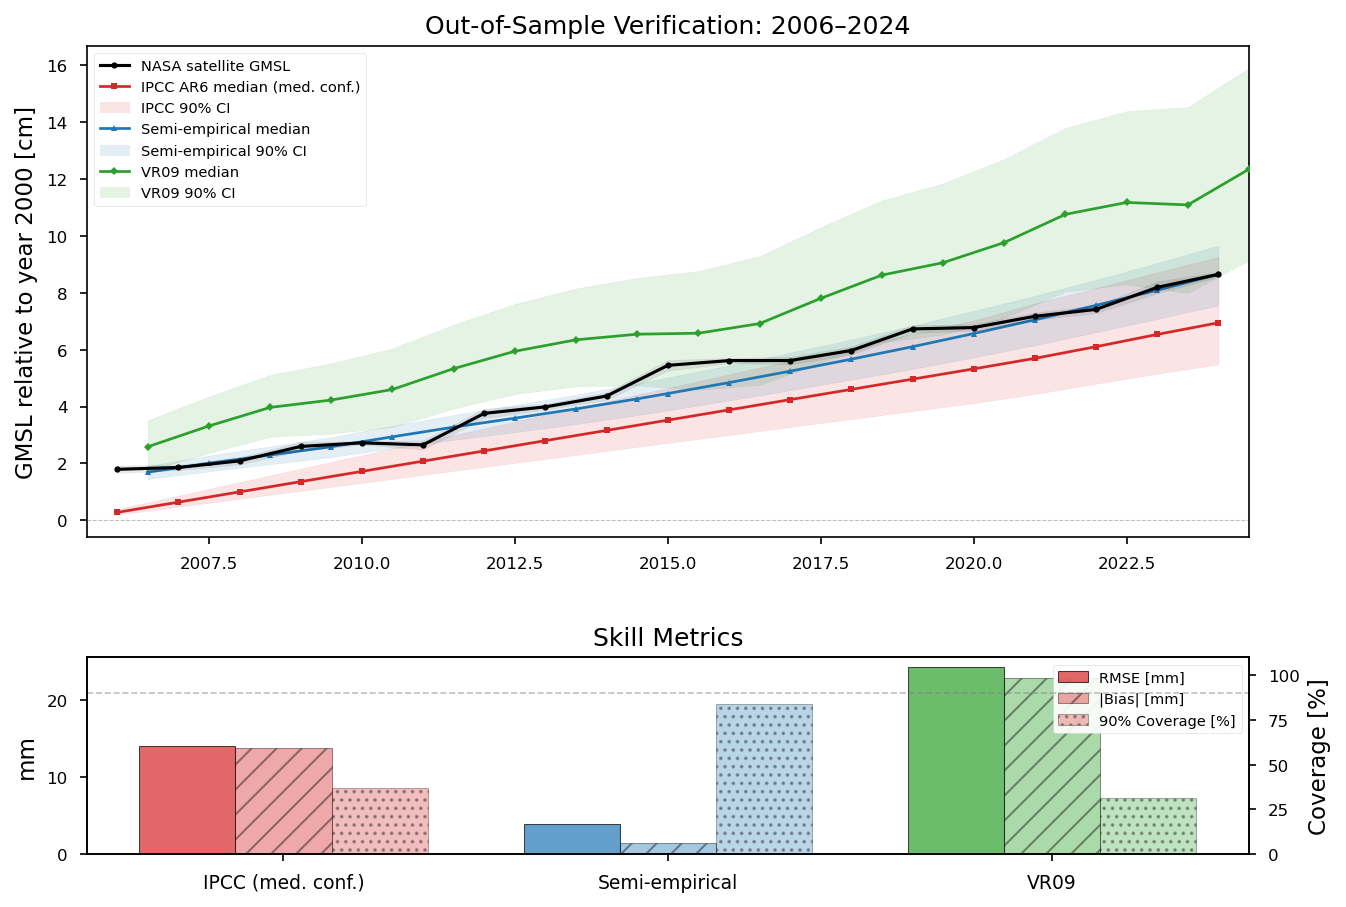


OUT-OF-SAMPLE VERIFICATION METRICS  (2006–2024 vs NASA satellite GMSL)
Model                           RMSE [mm]  Bias [mm]    90% Cov
--------------------------------------------------------------
  ISMIP6-emu                        17.82     +17.32        0%
  FittedISMIP + AR5                 12.21     +11.90       32%
  LARMIP + ISMIP6-emu               15.84     +15.45       47%
  LARMIP + FittedISMIP              10.08      +9.69       74%
  DP16 + ISMIP6-emu                 17.23     +16.76        0%
  DP16 + FittedISMIP                10.92     +10.59       37%
  Bamber SEJ                         8.74      +8.13       63%
  IPCC combined (med.conf.)         14.07     +13.73       37%
--------------------------------------------------------------
  Semi-empirical                     3.87      +1.37       84%
  VR09                              24.35     -22.90       32%
Figure 6 saved.


In [145]:
# ============================================================
# Figure 6: Direct out-of-sample verification (2006–2024)
# ============================================================
# Compare IPCC AR6 workflow projections and DOLS rate-and-state
# model against NASA satellite GMSL over the verification window.
#
# Upper panel: time-series comparison
# Lower panel: bar chart of skill metrics (bias, RMSE, coverage)

from slr_ar6_member_readers import WORKFLOW_INFO

# --- Skill metrics function ---
def compute_skill_metrics(obs, pred_median, pred_p5, pred_p95, label=''):
    """Compute bias, RMSE, and 90% CI coverage."""
    valid = np.isfinite(obs) & np.isfinite(pred_median)
    resid = obs[valid] - pred_median[valid]
    bias = np.mean(resid)
    rmse = np.sqrt(np.mean(resid**2))
    inside = ((obs[valid] >= pred_p5[valid]) &
              (obs[valid] <= pred_p95[valid]))
    coverage = np.mean(inside)
    return {'bias_mm': bias * M_TO_MM,
            'rmse_mm': rmse * M_TO_MM,
            'coverage_90': coverage,
            'label': label}

# --- Compute metrics for each IPCC workflow ---
skill_ipcc = {}
for key, data in sorted(wf_annual.items()):
    yrs = data['years']
    ens = data['ensemble']
    # Restrict to verification window
    vmask = np.isin(yrs, verif_years)
    if vmask.sum() == 0:
        continue
    ens_v = ens[:, vmask]
    med_v = np.median(ens_v, axis=0)
    p5_v = np.percentile(ens_v, 5, axis=0)
    p95_v = np.percentile(ens_v, 95, axis=0)
    wf_name = key.split('/')[0]
    label = WORKFLOW_INFO.get(wf_name, {}).get('label', wf_name)
    skill_ipcc[key] = compute_skill_metrics(
        nasa_verif_gmsl, med_v, p5_v, p95_v, label=label)

# Combined medium-confidence
vmask_c = np.isin(med_years, verif_years)
med_v = np.median(med_conf_ensemble[:, vmask_c], axis=0)
p5_v = np.percentile(med_conf_ensemble[:, vmask_c], 5, axis=0)
p95_v = np.percentile(med_conf_ensemble[:, vmask_c], 95, axis=0)
skill_ipcc_combined = compute_skill_metrics(
    nasa_verif_gmsl, med_v, p5_v, p95_v, label='IPCC (med. conf.)')

# --- DOLS metrics ---
dols_vmask = np.isin(dols_time.astype(int), verif_years.astype(int))
dols_v = dols_ensemble[:, dols_vmask]
dols_med_v = np.median(dols_v, axis=0)
dols_p5_v = np.percentile(dols_v, 5, axis=0)
dols_p95_v = np.percentile(dols_v, 95, axis=0)
skill_dols = compute_skill_metrics(
    nasa_verif_gmsl, dols_med_v, dols_p5_v, dols_p95_v,
    label='Semi-empirical')

# --- VR09 metrics ---
vr_vmask = np.isin(vr09_time.astype(int), verif_years.astype(int))
vr_v = vr09_ensemble[:, vr_vmask]
# Align lengths (in case of off-by-one from rounding)
n_vr_match = min(vr_v.shape[1], len(nasa_verif_gmsl))
vr_med_v = np.median(vr_v[:, :n_vr_match], axis=0)
vr_p5_v = np.percentile(vr_v[:, :n_vr_match], 5, axis=0)
vr_p95_v = np.percentile(vr_v[:, :n_vr_match], 95, axis=0)
skill_vr09 = compute_skill_metrics(
    nasa_verif_gmsl[:n_vr_match], vr_med_v, vr_p5_v, vr_p95_v,
    label='VR09')

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 7),
                         gridspec_kw={'height_ratios': [2.5, 1],
                                      'hspace': 0.35})
CM = M_TO_MM / 10   # meters → cm

# --- Upper panel: time-series ---
ax = axes[0]

# NASA observations
ax.plot(verif_years, nasa_verif_gmsl * CM, 'ko-', ms=3, lw=1.5,
        label='NASA satellite GMSL', zorder=10)
ax.fill_between(verif_years,
                (nasa_verif_gmsl - 1.645*nasa_verif_sigma) * CM,
                (nasa_verif_gmsl + 1.645*nasa_verif_sigma) * CM,
                color='k', alpha=0.08, zorder=9)

# IPCC combined medium-confidence
ipcc_yrs = med_years[vmask_c]
ax.plot(ipcc_yrs, med_v * CM, 's-', color='tab:red', ms=3, lw=1.3,
        label='IPCC AR6 median (med. conf.)', zorder=8)
ax.fill_between(ipcc_yrs, p5_v * CM, p95_v * CM,
                color='tab:red', alpha=0.12, label='IPCC 90% CI')

# DOLS rate-and-state
dols_yrs = dols_time[dols_vmask]
ax.plot(dols_yrs, dols_med_v * CM, '^-', color='tab:blue', ms=3, lw=1.3,
        label='Semi-empirical median', zorder=8)
ax.fill_between(dols_yrs, dols_p5_v * CM, dols_p95_v * CM,
                color='tab:blue', alpha=0.12, label='Semi-empirical 90% CI')

# VR09
vr_yrs = vr09_time[vr_vmask][:n_vr_match]
ax.plot(vr_yrs, vr_med_v * CM, 'D-', color='tab:green', ms=2.5, lw=1.3,
        label='VR09 median', zorder=7)
ax.fill_between(vr_yrs, vr_p5_v * CM, vr_p95_v * CM,
                color='tab:green', alpha=0.12, label='VR09 90% CI')

ax.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)
ax.set_xlim(VERIF_START - 0.5, VERIF_END + 0.5)
ax.set_ylabel('GMSL relative to year 2000 [cm]')
ax.set_title(f'Out-of-Sample Verification: {VERIF_START}–{VERIF_END}')
ax.legend(fontsize=7, loc='upper left', framealpha=0.9)

# --- Lower panel: skill metrics bar chart ---
ax2 = axes[1]

# Collect all models for comparison
bar_data = [skill_ipcc_combined, skill_dols, skill_vr09]
bar_labels = [d['label'] for d in bar_data]
bar_colors = ['tab:red', 'tab:blue', 'tab:green']
x = np.arange(len(bar_data))
width = 0.25

# RMSE bars
b1 = ax2.bar(x - width, [d['rmse_mm'] for d in bar_data], width,
             color=bar_colors, alpha=0.7, label='RMSE [mm]',
             edgecolor='k', linewidth=0.5)
# |Bias| bars
b2 = ax2.bar(x, [abs(d['bias_mm']) for d in bar_data], width,
             color=bar_colors, alpha=0.4, label='|Bias| [mm]',
             edgecolor='k', linewidth=0.5, hatch='//')
# Coverage (on twin axis)
ax2b = ax2.twinx()
b3 = ax2b.bar(x + width, [d['coverage_90']*100 for d in bar_data], width,
              color=bar_colors, alpha=0.3, label='90% Coverage [%]',
              edgecolor='k', linewidth=0.5, hatch='...')
ax2b.axhline(90, color='gray', ls='--', lw=0.8, alpha=0.5)
ax2b.set_ylabel('Coverage [%]')
ax2b.set_ylim(0, 110)

ax2.set_xticks(x)
ax2.set_xticklabels(bar_labels, fontsize=9)
ax2.set_ylabel('mm')
ax2.set_title('Skill Metrics')

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2,
           fontsize=7, loc='upper right', framealpha=0.9)

fig.savefig('../figures/stats_v_process_fig6_verification.png',
            dpi=200, bbox_inches='tight')
plt.show()

# --- Print detailed metrics ---
print('\n' + '='*72)
print('OUT-OF-SAMPLE VERIFICATION METRICS  (2006–2024 vs NASA satellite GMSL)')
print('='*72)
print(f'{"Model":<30} {"RMSE [mm]":>10} {"Bias [mm]":>10} {"90% Cov":>10}')
print('-'*62)
for key, s in sorted(skill_ipcc.items()):
    print(f'  {s["label"]:<28} {s["rmse_mm"]:>10.2f} {s["bias_mm"]:>+10.2f} '
          f'{s["coverage_90"]:>9.0%}')
print(f'  {"IPCC combined (med.conf.)":<28} '
      f'{skill_ipcc_combined["rmse_mm"]:>10.2f} '
      f'{skill_ipcc_combined["bias_mm"]:>+10.2f} '
      f'{skill_ipcc_combined["coverage_90"]:>9.0%}')
print('-'*62)
print(f'  {skill_dols["label"]:<28} {skill_dols["rmse_mm"]:>10.2f} '
      f'{skill_dols["bias_mm"]:>+10.2f} {skill_dols["coverage_90"]:>9.0%}')
print(f'  {skill_vr09["label"]:<28} {skill_vr09["rmse_mm"]:>10.2f} '
      f'{skill_vr09["bias_mm"]:>+10.2f} {skill_vr09["coverage_90"]:>9.0%}')
print('Figure 6 saved.')


PIT values computed: IPCC 19, DOLS 19, VR09 19
IPCC PIT mean = 0.956 (ideal 0.50, >0.5 → obs above ensemble)
DOLS PIT mean = 0.762
VR09 PIT mean = 0.072


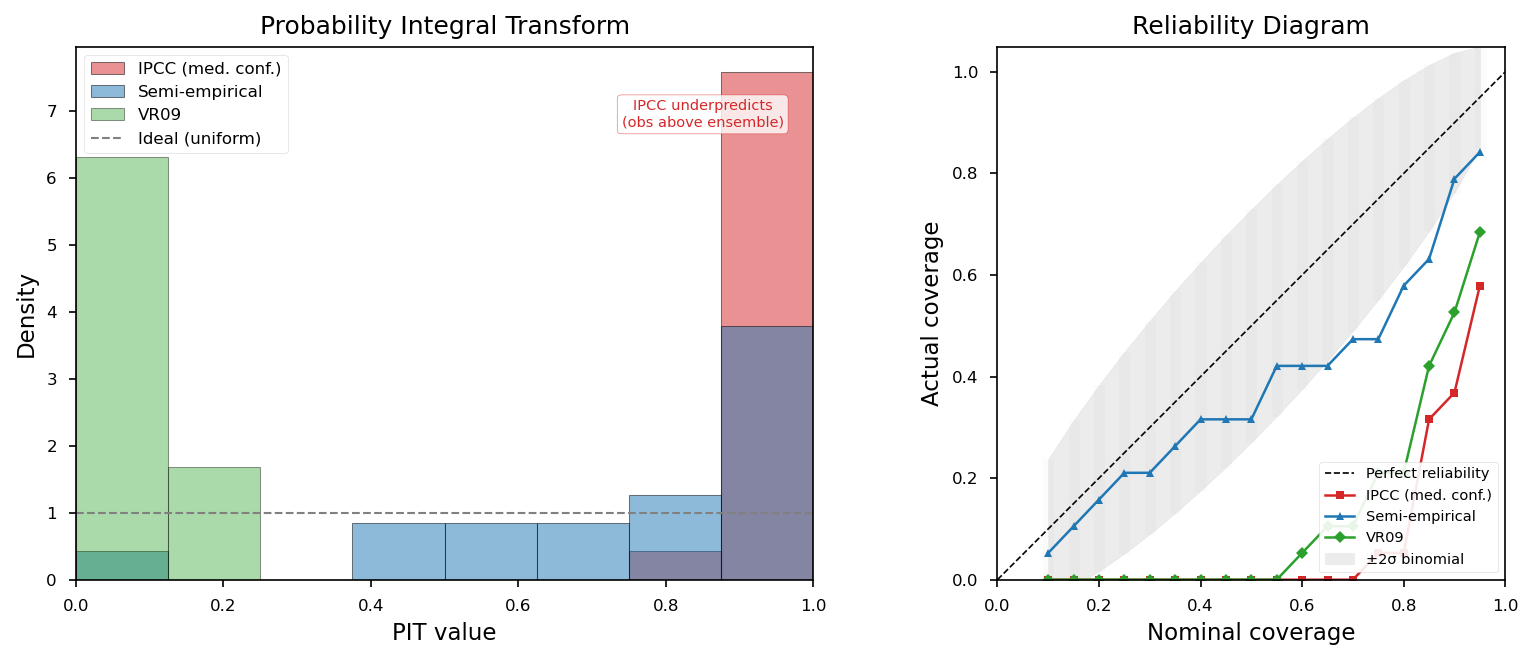


RELIABILITY ANALYSIS SUMMARY

PIT uniformity (KS test, H0: PIT ~ Uniform[0,1]):
  IPCC:  KS = 0.875, p = 0.000
  DOLS:  KS = 0.412, p = 0.002
  VR09:  KS = 0.778, p = 0.000

Coverage at key nominal levels:
   Nominal      IPCC      DOLS      VR09
      50%       0%      32%       0%
      80%       5%      58%      21%
      90%      37%      79%      53%
      95%      58%      84%      68%
Figure 7 saved.


In [146]:
# ============================================================
# Figure 7: Reliability analysis — PIT + coverage diagrams
# ============================================================
# Left:  PIT histograms (probability integral transform) for
#         IPCC medium-confidence and DOLS ensembles
# Right: Reliability diagram (nominal vs actual coverage)
#
# If the ensemble is well-calibrated, PIT values are uniform
# (flat histogram) and the reliability curve follows the diagonal.

from scipy import stats as sp_stats

# ============================================================
# Compute PIT values
# ============================================================
def compute_pit(obs_annual, ensemble, ens_years, verif_yrs):
    """Compute PIT value at each verification year.

    PIT = fraction of ensemble members below the observation.
    """
    pit = []
    for j, yr in enumerate(verif_yrs):
        idx = np.argmin(np.abs(ens_years - yr))
        if np.abs(ens_years[idx] - yr) > 0.6:
            continue
        samples = ensemble[:, idx]
        pit_val = np.mean(samples < obs_annual[j])
        pit.append(pit_val)
    return np.array(pit)

# IPCC combined medium-confidence
pit_ipcc = compute_pit(nasa_verif_gmsl, med_conf_ensemble,
                       med_years, verif_years)

# DOLS ensemble
pit_dols = compute_pit(nasa_verif_gmsl, dols_ensemble,
                       dols_time, verif_years)

# VR09 ensemble
pit_vr09 = compute_pit(nasa_verif_gmsl, vr09_ensemble,
                        vr09_time, verif_years)

print(f'PIT values computed: IPCC {len(pit_ipcc)}, '
      f'DOLS {len(pit_dols)}, VR09 {len(pit_vr09)}')
print(f'IPCC PIT mean = {np.mean(pit_ipcc):.3f} '
      f'(ideal 0.50, >0.5 → obs above ensemble)')
print(f'DOLS PIT mean = {np.mean(pit_dols):.3f}')
print(f'VR09 PIT mean = {np.mean(pit_vr09):.3f}')

# ============================================================
# Coverage at multiple nominal levels
# ============================================================
def compute_coverage_curve(obs_annual, ensemble, ens_years, verif_yrs,
                           nominal_levels=None):
    """Compute actual coverage at a range of nominal levels."""
    if nominal_levels is None:
        nominal_levels = np.arange(0.10, 1.0, 0.05)
    actual = np.zeros(len(nominal_levels))
    for j_lvl, nom in enumerate(nominal_levels):
        alpha = 1 - nom
        lo_pct = 100 * alpha / 2
        hi_pct = 100 * (1 - alpha / 2)
        inside_count = 0
        total_count = 0
        for j, yr in enumerate(verif_yrs):
            idx = np.argmin(np.abs(ens_years - yr))
            if np.abs(ens_years[idx] - yr) > 0.6:
                continue
            samples = ensemble[:, idx]
            lo = np.percentile(samples, lo_pct)
            hi = np.percentile(samples, hi_pct)
            if lo <= obs_annual[j] <= hi:
                inside_count += 1
            total_count += 1
        actual[j_lvl] = inside_count / total_count if total_count > 0 else np.nan
    return nominal_levels, actual

nom_levels = np.arange(0.10, 1.0, 0.05)
_, cov_ipcc = compute_coverage_curve(
    nasa_verif_gmsl, med_conf_ensemble, med_years, verif_years, nom_levels)
_, cov_dols = compute_coverage_curve(
    nasa_verif_gmsl, dols_ensemble, dols_time, verif_years, nom_levels)
_, cov_vr09 = compute_coverage_curve(
    nasa_verif_gmsl, vr09_ensemble, vr09_time, verif_years, nom_levels)

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Left: PIT histograms ---
ax1 = axes[0]
n_bins = 8
ax1.hist(pit_ipcc, bins=n_bins, range=(0, 1), density=True,
         alpha=0.5, color='tab:red', edgecolor='k', linewidth=0.5,
         label='IPCC (med. conf.)')
ax1.hist(pit_dols, bins=n_bins, range=(0, 1), density=True,
         alpha=0.5, color='tab:blue', edgecolor='k', linewidth=0.5,
         label='Semi-empirical')
ax1.hist(pit_vr09, bins=n_bins, range=(0, 1), density=True,
         alpha=0.4, color='tab:green', edgecolor='k', linewidth=0.5,
         label='VR09')
ax1.axhline(1.0, color='gray', ls='--', lw=1, label='Ideal (uniform)')
ax1.set_xlabel('PIT value')
ax1.set_ylabel('Density')
ax1.set_title('Probability Integral Transform')
ax1.set_xlim(0, 1)
ax1.legend(fontsize=8, framealpha=0.9)

# Annotate bias direction
if np.mean(pit_ipcc) > 0.6:
    ax1.annotate('IPCC underpredicts\n(obs above ensemble)',
                 xy=(0.85, 0.85), xycoords='axes fraction',
                 fontsize=7, ha='center', color='tab:red',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white',
                           ec='tab:red', alpha=0.8))
elif np.mean(pit_ipcc) < 0.4:
    ax1.annotate('IPCC overpredicts\n(obs below ensemble)',
                 xy=(0.85, 0.85), xycoords='axes fraction',
                 fontsize=7, ha='center', color='tab:red',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white',
                           ec='tab:red', alpha=0.8))

# --- Right: reliability diagram ---
ax2 = axes[1]
ax2.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect reliability')
ax2.plot(nom_levels, cov_ipcc, 's-', color='tab:red', ms=4, lw=1.2,
         label='IPCC (med. conf.)')
ax2.plot(nom_levels, cov_dols, '^-', color='tab:blue', ms=4, lw=1.2,
         label='Semi-empirical')
ax2.plot(nom_levels, cov_vr09, 'D-', color='tab:green', ms=4, lw=1.2,
         label='VR09')

# Consistency band: ±2σ for binomial proportion
n_verif = len(verif_years)
for nom in nom_levels:
    se = np.sqrt(nom * (1 - nom) / n_verif)
    ax2.fill_between([nom - 0.01, nom + 0.01],
                     nom - 2*se, nom + 2*se,
                     color='gray', alpha=0.03)
# Simplified band at the edges
band_lo = nom_levels - 2*np.sqrt(nom_levels*(1-nom_levels)/n_verif)
band_hi = nom_levels + 2*np.sqrt(nom_levels*(1-nom_levels)/n_verif)
ax2.fill_between(nom_levels, band_lo, band_hi,
                 color='gray', alpha=0.15, label='±2σ binomial')

ax2.set_xlabel('Nominal coverage')
ax2.set_ylabel('Actual coverage')
ax2.set_title('Reliability Diagram')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.05)
ax2.set_aspect('equal')
ax2.legend(fontsize=7, loc='lower right', framealpha=0.9)

fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig7_reliability.png',
            dpi=200, bbox_inches='tight')
plt.show()

# --- Print PIT summary statistics ---
print('\n' + '='*60)
print('RELIABILITY ANALYSIS SUMMARY')
print('='*60)
# KS test for uniformity
ks_ipcc = sp_stats.kstest(pit_ipcc, 'uniform')
ks_dols = sp_stats.kstest(pit_dols, 'uniform')
ks_vr09 = sp_stats.kstest(pit_vr09, 'uniform')
print(f'\nPIT uniformity (KS test, H0: PIT ~ Uniform[0,1]):')
print(f'  IPCC:  KS = {ks_ipcc.statistic:.3f}, p = {ks_ipcc.pvalue:.3f}')
print(f'  DOLS:  KS = {ks_dols.statistic:.3f}, p = {ks_dols.pvalue:.3f}')
print(f'  VR09:  KS = {ks_vr09.statistic:.3f}, p = {ks_vr09.pvalue:.3f}')
print(f'\nCoverage at key nominal levels:')
print(f'  {"Nominal":>8}  {"IPCC":>8}  {"DOLS":>8}  {"VR09":>8}')
for nom_val in [0.50, 0.80, 0.90, 0.95]:
    idx = np.argmin(np.abs(nom_levels - nom_val))
    print(f'  {nom_levels[idx]:>7.0%}  {cov_ipcc[idx]:>7.0%}  '
          f'{cov_dols[idx]:>7.0%}  {cov_vr09[idx]:>7.0%}')
print('Figure 7 saved.')


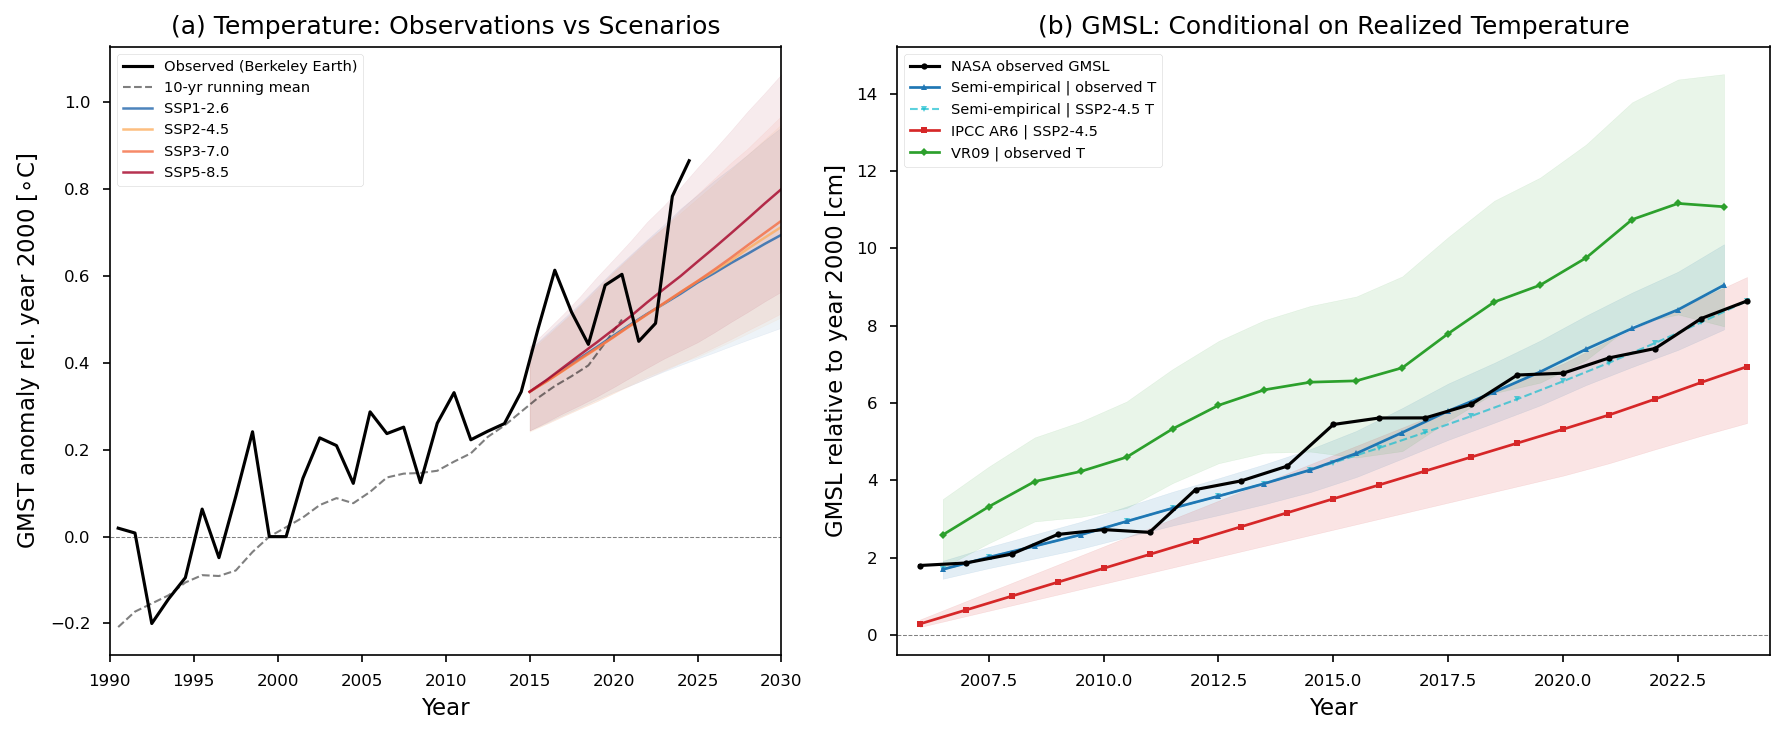


CONDITIONAL SKILL ANALYSIS  (2006–2024 vs NASA satellite GMSL)

Model                             RMSE [mm]  Bias [mm]    90% Cov
-----------------------------------------------------------------
  Semi-empirical | observed T          5.46      -2.47       89%
  Semi-empirical | SSP2-4.5 T          3.87      +1.37         —
  IPCC AR6 | SSP2-4.5                 14.07     +13.73       37%
  VR09 | observed T                   23.62     -22.35       37%

Note: "observed T" means Berkeley Earth GMST only (no SSP switch).
      IPCC projections cannot be re-run with observed T, but SSP2-4.5
      closely tracks observed warming through 2024 (panel a).
Figure 8 saved.


In [147]:
# ============================================================
# Figure 8: Conditional skill — predictions given realized T
# ============================================================
# Key question: given the temperature that ACTUALLY occurred,
# how well does each model predict the sea level that occurred?
#
# Left panel:  Observed GMST vs SSP projections (2000–2030)
#              → shows SSP2-4.5 tracks observations well
# Right panel: GMSL predictions conditional on observed T
#              vs predictions conditional on SSP2-4.5 T
#              vs NASA satellite observations
#
# This isolates the sea-level response model from scenario
# uncertainty: the DOLS model can be directly evaluated with
# observed T, while IPCC cannot be re-run but SSP2-4.5 ≈ obs.

CM = M_TO_MM / 10

# ============================================================
# Left panel: temperature context
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         gridspec_kw={'width_ratios': [1, 1.3]})

ax_t = axes[0]

# Observed GMST (Berkeley Earth, rebased to yr 2000)
t_mask = ((temp_annual['year'] >= 1990) &
          (temp_annual['year'] <= 2030))
ax_t.plot(temp_annual['year'].values[t_mask],
          temp_annual['temperature_rb'].values[t_mask],
          'k-', lw=1.5, label='Observed (Berkeley Earth)', zorder=10)
ax_t.plot(temp_annual['year'].values[t_mask],
          temp_annual['temp_smooth_rb'].values[t_mask],
          'k--', lw=1, alpha=0.5, label='10-yr running mean')

# SSP projections (rebased to yr 2000)
ssp_colors = {'SSP1-2.6': '#2166ac', 'SSP2-4.5': '#fdae61',
              'SSP3-7.0': '#f46d43', 'SSP5-8.5': '#a50026'}
for ssp_name in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
    tp = temp_proj_rb[ssp_name]
    tp_mask = tp['decimal_year'] <= 2030
    ax_t.plot(tp['decimal_year'].values[tp_mask],
              tp['temperature'].values[tp_mask],
              color=ssp_colors[ssp_name], lw=1.2,
              label=ssp_name, alpha=0.8)
    if 'temperature_lower' in tp.columns:
        ax_t.fill_between(
            tp['decimal_year'].values[tp_mask],
            tp['temperature_lower'].values[tp_mask],
            tp['temperature_upper'].values[tp_mask],
            color=ssp_colors[ssp_name], alpha=0.08)

ax_t.axhline(0, color='gray', ls='--', lw=0.5)
ax_t.set_xlim(1990, 2030)
ax_t.set_xlabel('Year')
ax_t.set_ylabel(r'GMST anomaly rel. year 2000 [$\circ$C]')
ax_t.set_title('(a) Temperature: Observations vs Scenarios')
ax_t.legend(fontsize=7, loc='upper left', framealpha=0.9)

# ============================================================
# Right panel: GMSL conditional on temperature
# ============================================================
ax_s = axes[1]

# NASA observations
obs_mask = ((verif_years >= VERIF_START) & (verif_years <= VERIF_END))
ax_s.plot(verif_years[obs_mask],
          nasa_verif_gmsl[obs_mask] * CM,
          'ko-', ms=3, lw=1.5, label='NASA observed GMSL', zorder=10)

# DOLS conditional on observed T only (no SSP)
obs_t_mask = ((dols_obs_time >= VERIF_START) &
              (dols_obs_time <= VERIF_END))
dols_obs_med = np.median(dols_obs_ensemble, axis=0)
dols_obs_p5 = np.percentile(dols_obs_ensemble, 5, axis=0)
dols_obs_p95 = np.percentile(dols_obs_ensemble, 95, axis=0)
ax_s.plot(dols_obs_time[obs_t_mask], dols_obs_med[obs_t_mask] * CM,
          '^-', color='tab:blue', ms=3, lw=1.3,
          label='Semi-empirical | observed T', zorder=8)
ax_s.fill_between(dols_obs_time[obs_t_mask],
                  dols_obs_p5[obs_t_mask] * CM,
                  dols_obs_p95[obs_t_mask] * CM,
                  color='tab:blue', alpha=0.12)

# DOLS conditional on SSP2-4.5 T (from dols_ensemble)
ssp_t_mask = ((dols_time >= VERIF_START) & (dols_time <= VERIF_END))
dols_ssp_med = np.median(dols_ensemble, axis=0)
dols_ssp_p5 = np.percentile(dols_ensemble, 5, axis=0)
dols_ssp_p95 = np.percentile(dols_ensemble, 95, axis=0)
ax_s.plot(dols_time[ssp_t_mask], dols_ssp_med[ssp_t_mask] * CM,
          'v--', color='tab:cyan', ms=3, lw=1,
          label='Semi-empirical | SSP2-4.5 T', alpha=0.7, zorder=7)

# IPCC (cannot be re-run; show SSP2-4.5 projection)
ipcc_vmask = np.isin(med_years, verif_years)
ipcc_med_v = np.median(med_conf_ensemble[:, ipcc_vmask], axis=0)
ipcc_p5_v = np.percentile(med_conf_ensemble[:, ipcc_vmask], 5, axis=0)
ipcc_p95_v = np.percentile(med_conf_ensemble[:, ipcc_vmask], 95, axis=0)
ipcc_yrs_v = med_years[ipcc_vmask]
ax_s.plot(ipcc_yrs_v, ipcc_med_v * CM, 's-', color='tab:red', ms=3, lw=1.3,
          label='IPCC AR6 | SSP2-4.5', zorder=8)
ax_s.fill_between(ipcc_yrs_v, ipcc_p5_v * CM, ipcc_p95_v * CM,
                  color='tab:red', alpha=0.12)

# VR09 conditional on observed T only
vr_obs_tmask = ((vr09_obs_time >= VERIF_START) &
                (vr09_obs_time <= VERIF_END))
vr_obs_med = np.median(vr09_obs_ensemble, axis=0)
vr_obs_p5 = np.percentile(vr09_obs_ensemble, 5, axis=0)
vr_obs_p95 = np.percentile(vr09_obs_ensemble, 95, axis=0)
ax_s.plot(vr09_obs_time[vr_obs_tmask], vr_obs_med[vr_obs_tmask] * CM,
          'D-', color='tab:green', ms=2.5, lw=1.3,
          label='VR09 | observed T', zorder=7)
ax_s.fill_between(vr09_obs_time[vr_obs_tmask],
                  vr_obs_p5[vr_obs_tmask] * CM,
                  vr_obs_p95[vr_obs_tmask] * CM,
                  color='tab:green', alpha=0.10)

ax_s.axhline(0, color='gray', ls='--', lw=0.5)
ax_s.set_xlim(VERIF_START - 0.5, VERIF_END + 0.5)
ax_s.set_xlabel('Year')
ax_s.set_ylabel('GMSL relative to year 2000 [cm]')
ax_s.set_title('(b) GMSL: Conditional on Realized Temperature')
ax_s.legend(fontsize=7, loc='upper left', framealpha=0.9)

fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig8_conditional.png',
            dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# Conditional skill metrics
# ============================================================
# DOLS | observed T
dols_obs_vmask = np.isin(dols_obs_time.astype(int), verif_years.astype(int))
dols_obs_v = dols_obs_ensemble[:, dols_obs_vmask]
# Match verification years
n_match = min(dols_obs_v.shape[1], len(nasa_verif_gmsl))
obs_for_cond = nasa_verif_gmsl[:n_match]
dols_obs_v = dols_obs_v[:, :n_match]

resid_obs = obs_for_cond - np.median(dols_obs_v, axis=0)
rmse_obs = np.sqrt(np.mean(resid_obs**2)) * M_TO_MM
bias_obs = np.mean(resid_obs) * M_TO_MM
inside_obs = ((obs_for_cond >= np.percentile(dols_obs_v, 5, axis=0)) &
              (obs_for_cond <= np.percentile(dols_obs_v, 95, axis=0)))
cov_obs = np.mean(inside_obs)

# DOLS | SSP T
dols_ssp_v = dols_ensemble[:, dols_vmask][:, :n_match]
resid_ssp = obs_for_cond - np.median(dols_ssp_v, axis=0)
rmse_ssp = np.sqrt(np.mean(resid_ssp**2)) * M_TO_MM
bias_ssp = np.mean(resid_ssp) * M_TO_MM

print('\n' + '='*65)
print('CONDITIONAL SKILL ANALYSIS  (2006–2024 vs NASA satellite GMSL)')
print('='*65)
print(f'\n{"Model":<32} {"RMSE [mm]":>10} {"Bias [mm]":>10} {"90% Cov":>10}')
print('-'*65)
print(f'  {"Semi-empirical | observed T":<30} {rmse_obs:>10.2f} {bias_obs:>+10.2f} '
      f'{cov_obs:>9.0%}')
print(f'  {"Semi-empirical | SSP2-4.5 T":<30} {rmse_ssp:>10.2f} {bias_ssp:>+10.2f} '
      f'{"—":>9}')
print(f'  {"IPCC AR6 | SSP2-4.5":<30} '
      f'{skill_ipcc_combined["rmse_mm"]:>10.2f} '
      f'{skill_ipcc_combined["bias_mm"]:>+10.2f} '
      f'{skill_ipcc_combined["coverage_90"]:>9.0%}')

# VR09 | observed T
vr_obs_vmask = np.isin(vr09_obs_time.astype(int), verif_years.astype(int))
vr_obs_v = vr09_obs_ensemble[:, vr_obs_vmask]
n_vr_match = min(vr_obs_v.shape[1], len(nasa_verif_gmsl))
obs_vr = nasa_verif_gmsl[:n_vr_match]
vr_obs_v = vr_obs_v[:, :n_vr_match]
resid_vr = obs_vr - np.median(vr_obs_v, axis=0)
rmse_vr = np.sqrt(np.mean(resid_vr**2)) * M_TO_MM
bias_vr = np.mean(resid_vr) * M_TO_MM
inside_vr = ((obs_vr >= np.percentile(vr_obs_v, 5, axis=0)) &
             (obs_vr <= np.percentile(vr_obs_v, 95, axis=0)))
cov_vr = np.mean(inside_vr)
print(f'  {"VR09 | observed T":<30} {rmse_vr:>10.2f} {bias_vr:>+10.2f} '
      f'{cov_vr:>9.0%}')
print()
print('Note: "observed T" means Berkeley Earth GMST only (no SSP switch).')
print('      IPCC projections cannot be re-run with observed T, but SSP2-4.5')
print('      closely tracks observed warming through 2024 (panel a).')
print('Figure 8 saved.')


## 8. Forecast Horizon Analysis

How does forecast skill degrade with prediction horizon? Three complementary diagnostics:

- **B. Hindcast degradation curve** — Leave-future-out cross-validation with multiple cutoff years; RMSE and coverage as a function of lead time.
- **C. Temperature exceedance** — How far beyond the calibration range is each projection year? Relates extrapolation distance to forecast error.
- **D. Cross-model divergence** — When do structurally different models disagree? Divergence marks the boundary of reliable prediction.

DOLS cutoff 1960: a=1.927, RMSE=39.9 mm, 90%cov=100%
DOLS cutoff 1970: a=2.040, RMSE=17.2 mm, 90%cov=94%
DOLS cutoff 1980: a=3.128, RMSE=7.7 mm, 90%cov=79%
DOLS cutoff 1990: a=3.385, RMSE=14.7 mm, 90%cov=36%
DOLS cutoff 2000: a=4.402, RMSE=10.6 mm, 90%cov=72%
DOLS cutoff 2010: a=5.998, RMSE=4.7 mm, 90%cov=75%
VR09 cutoff 1960: T0=-1.2863, RMSE=59.3 mm, 90%cov=9%
VR09 cutoff 1970: T0=-1.1581, RMSE=36.8 mm, 90%cov=12%
VR09 cutoff 1980: T0=-1.0689, RMSE=24.9 mm, 90%cov=16%
VR09 cutoff 1990: T0=-0.9589, RMSE=17.1 mm, 90%cov=36%
VR09 cutoff 2000: T0=-0.8578, RMSE=15.1 mm, 90%cov=33%
VR09 cutoff 2010: T0=-0.8654, RMSE=18.1 mm, 90%cov=62%


/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_69451/290237722.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


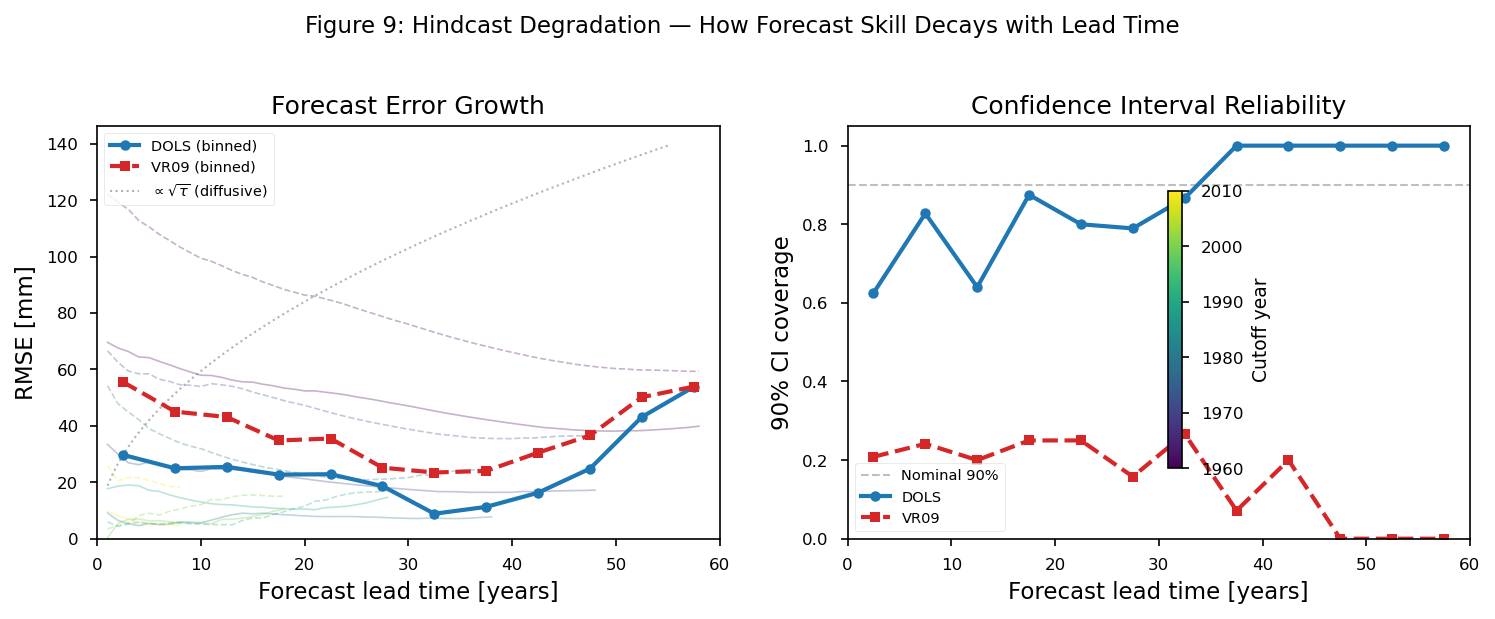


Binned degradation summary:
 Lead (yr)  DOLS RMSE  VR09 RMSE   DOLS Cov   VR09 Cov  n_DOLS  n_VR09
         2       29.7       55.5        62%        21%      24      24
         8       24.9       45.0        83%        24%      29      29
        12       25.5       43.1        64%        20%      25      25
        18       22.7       34.8        88%        25%      24      24
        22       22.9       35.5        80%        25%      20      20
        28       18.7       25.2        79%        16%      19      19
        32        8.9       23.5        87%        27%      15      15
        38       11.3       24.0       100%         7%      14      14
        42       16.3       30.5       100%        20%      10      10
        48       24.8       36.6       100%         0%       9       9
        52       43.1       50.1       100%         0%       5       5
        58       53.8       53.9       100%         0%       4       4


In [148]:
# ============================================================
# Approach B: Hindcast degradation curve
# ============================================================
# Leave-future-out cross-validation with multiple cutoff years.
# For each cutoff:
#   DOLS — re-calibrate Bayesian level-space model on data <= cutoff
#   VR09 — re-fit T0 on Frederikse <= cutoff (a, b published)
# Project forward using observed temperature only, compute RMSE
# and 90% CI coverage as a function of forecast lead time.
#
# Dependencies: cells 3, 5, 8, 14 (priors), 21 (VR09)
# ============================================================

from scipy.optimize import minimize_scalar
from collections import defaultdict

DEGRAD_CUTOFFS = [1960, 1970, 1980, 1990, 2000, 2010]

# Observed-only temperature for forward projection (calibration baseline)
_temp_obs_proj = temp_annual_for_proj.copy()
_temp_obs_proj.index = pd.to_datetime(
    _temp_obs_proj['decimal_year'].astype(int).astype(str) + '-01-01'
)

# ============================================================
# A. DOLS Bayesian level-space: re-calibrate for each cutoff
# ============================================================
degrad_dols = {}

for cut_yr in DEGRAD_CUTOFFS:
    # Truncate calibration data
    obs_mask_cal = (fred_time >= HINDCAST_START_YEAR) & (fred_time <= cut_yr)
    obs_years_cal = fred_time[obs_mask_cal]
    H_obs_cal = fred_gmsl[obs_mask_cal]          # native baseline (m)
    sigma_cal = fred_gmsl_sigma[obs_mask_cal]

    if len(obs_years_cal) < 30:
        print(f'DOLS: skipping cutoff {cut_yr} (only {len(obs_years_cal)} obs)')
        continue

    # Monthly temperature for calibration window
    mask_m = ((time_monthly_all >= obs_years_cal[0]) &
              (time_monthly_all <= obs_years_cal[-1] + 0.99))
    T_m_cal = T_monthly_all[mask_m]
    t_m_cal = time_monthly_all[mask_m]

    # Design vectors
    dv = build_level_design_vectors(
        temperature_monthly=T_m_cal,
        time_monthly=t_m_cal,
        obs_times=obs_years_cal,
    )

    # Bayesian fit
    try:
        res = fit_bayesian_level(
            H_obs=H_obs_cal, sigma_obs=sigma_cal,
            I2_obs=dv['I2_obs'], I1_obs=dv['I1_obs'], I0_obs=dv['I0_obs'],
            prior_scale_a=PRIOR_SCALE_A, prior_scale_b=PRIOR_SCALE_B,
            prior_c_mean=PRIOR_C_MEAN, prior_c_sigma=PRIOR_C_SIGMA,
            prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
            prior_H0_sigma=PRIOR_H0_SIGMA,
            n_samples=2000, n_walkers=32, n_burnin=1000,
            progress=False, seed=42,
        )
    except Exception as e:
        print(f'DOLS: fit failed for cutoff {cut_yr}: {e}')
        continue

    # Project forward using observed-only temperature
    mc = project_gmsl_ensemble(
        coefficients=res.physical_coefficients,
        coefficients_cov=res.physical_covariance,
        temperature_projections={'obs': _temp_obs_proj},
        baseline_year=BASELINE_YEAR,
        baseline_gmsl=0.0,
        n_samples=N_SAMPLES,
        seed=42,
    )
    proj_df = mc['scenarios']['obs']
    proj_time = proj_df['decimal_year'].values
    proj_med  = proj_df['gmsl'].values
    proj_lo   = proj_df['gmsl_lower'].values
    proj_hi   = proj_df['gmsl_upper'].values

    # Verification against Frederikse (held-out years)
    verif_mask = fred_time > cut_yr
    vtime = fred_time[verif_mask]
    vobs  = fred_gmsl_rb[verif_mask]

    lead = vtime - cut_yr
    pred_m = np.interp(vtime, proj_time, proj_med)
    pred_l = np.interp(vtime, proj_time, proj_lo)
    pred_h = np.interp(vtime, proj_time, proj_hi)
    err    = vobs - pred_m
    in_ci  = (vobs >= pred_l) & (vobs <= pred_h)

    degrad_dols[cut_yr] = dict(
        lead=lead, error_mm=err * M_TO_MM, in_ci=in_ci,
        coeffs=res.physical_coefficients.copy(),
    )
    rmse = np.sqrt(np.mean(err**2)) * M_TO_MM
    print(f'DOLS cutoff {cut_yr}: a={res.physical_coefficients[0]*M_TO_MM:.3f}, '
          f'RMSE={rmse:.1f} mm, 90%cov={in_ci.mean():.0%}')

# ============================================================
# B. VR09: re-fit T0 for each cutoff (a, b published)
# ============================================================
degrad_vr09 = {}

for cut_yr in DEGRAD_CUTOFFS:
    # Truncate temperature at cutoff
    T_mask = time_vr_obs <= cut_yr
    T_cal = T_vr_obs[T_mask]
    t_cal = time_vr_obs[T_mask]

    # Frederikse for T0 calibration
    f_mask = (fred_time >= 1900) & (fred_time <= cut_yr)
    f_cal = fred_gmsl_rb[f_mask]
    f_t   = fred_time[f_mask]

    def _rmse_T0(T0_trial, _T=T_cal, _t=t_cal, _fo=f_cal, _ft=f_t):
        H = vr09_project(_T, _t, VR09_a, VR09_b, T0_trial,
                         baseline_year=BASELINE_YEAR)
        return np.sqrt(np.mean((_fo - np.interp(_ft, _t, H))**2))

    opt = minimize_scalar(_rmse_T0, bounds=(-2.0, 0.5), method='bounded')
    T0_fit = opt.x

    # MC ensemble on full observed temperature record
    N_ens = N_SAMPLES
    rng_v = np.random.default_rng(42 + cut_yr)
    a_s  = rng_v.normal(VR09_a, VR09_a_se, N_ens)
    b_s  = rng_v.normal(VR09_b, VR09_b_se, N_ens)
    T0_s = rng_v.normal(T0_fit, _T0_total_se, N_ens)

    ens = np.zeros((N_ens, len(T_vr_obs)))
    for k in range(N_ens):
        ens[k] = vr09_project(T_vr_obs, time_vr_obs,
                              a_s[k], b_s[k], T0_s[k],
                              baseline_year=BASELINE_YEAR)

    med = np.median(ens, axis=0)
    lo  = np.percentile(ens, 5, axis=0)
    hi  = np.percentile(ens, 95, axis=0)

    # Verification against Frederikse (held-out years)
    verif_mask = fred_time > cut_yr
    vtime = fred_time[verif_mask]
    vobs  = fred_gmsl_rb[verif_mask]

    lead = vtime - cut_yr
    pred_m = np.interp(vtime, time_vr_obs, med)
    pred_l = np.interp(vtime, time_vr_obs, lo)
    pred_h = np.interp(vtime, time_vr_obs, hi)
    err    = vobs - pred_m
    in_ci  = (vobs >= pred_l) & (vobs <= pred_h)

    degrad_vr09[cut_yr] = dict(
        lead=lead, error_mm=err * M_TO_MM, in_ci=in_ci, T0=T0_fit,
    )
    rmse = np.sqrt(np.mean(err**2)) * M_TO_MM
    print(f'VR09 cutoff {cut_yr}: T0={T0_fit:.4f}, '
          f'RMSE={rmse:.1f} mm, 90%cov={in_ci.mean():.0%}')

# ============================================================
# Figure 9: Hindcast degradation curves
# ============================================================
# Pool all (lead_time, |error|, in_ci) tuples across cutoffs,
# bin by 5-year lead-time windows, compute RMSE and coverage.

def _bin_skill(results_dict, bin_edges):
    """Bin errors by lead time and compute RMSE + coverage."""
    all_lead = np.concatenate([r['lead'] for r in results_dict.values()])
    all_err  = np.concatenate([r['error_mm'] for r in results_dict.values()])
    all_ci   = np.concatenate([r['in_ci'] for r in results_dict.values()])

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    rmse_bins = np.full(len(bin_centers), np.nan)
    cov_bins  = np.full(len(bin_centers), np.nan)
    n_bins    = np.zeros(len(bin_centers), dtype=int)

    for j in range(len(bin_centers)):
        mask = (all_lead >= bin_edges[j]) & (all_lead < bin_edges[j+1])
        n_bins[j] = mask.sum()
        if n_bins[j] >= 3:
            rmse_bins[j] = np.sqrt(np.mean(all_err[mask]**2))
            cov_bins[j]  = all_ci[mask].mean()

    return bin_centers, rmse_bins, cov_bins, n_bins

bin_edges = np.arange(0, 61, 5)  # 0–5, 5–10, ..., 55–60 yr
bc_dols, rmse_dols, cov_dols, n_dols = _bin_skill(degrad_dols, bin_edges)
bc_vr09, rmse_vr09, cov_vr09, n_vr09 = _bin_skill(degrad_vr09, bin_edges)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: RMSE vs lead time ---
ax = axes[0]

# Individual cutoff curves (thin, semi-transparent)
cmap = plt.cm.viridis
norm = plt.Normalize(min(DEGRAD_CUTOFFS), max(DEGRAD_CUTOFFS))
for cut_yr in sorted(degrad_dols.keys()):
    r = degrad_dols[cut_yr]
    color = cmap(norm(cut_yr))
    # Running RMSE (cumulative)
    cum_rmse = np.array([np.sqrt(np.mean(r['error_mm'][:i+1]**2))
                         for i in range(len(r['lead']))])
    ax.plot(r['lead'], cum_rmse, color=color, alpha=0.3, lw=0.8)

for cut_yr in sorted(degrad_vr09.keys()):
    r = degrad_vr09[cut_yr]
    color = cmap(norm(cut_yr))
    cum_rmse = np.array([np.sqrt(np.mean(r['error_mm'][:i+1]**2))
                         for i in range(len(r['lead']))])
    ax.plot(r['lead'], cum_rmse, color=color, alpha=0.3, lw=0.8, ls='--')

# Binned averages (thick)
valid_d = ~np.isnan(rmse_dols)
valid_v = ~np.isnan(rmse_vr09)
ax.plot(bc_dols[valid_d], rmse_dols[valid_d], 'o-', color='tab:blue',
        lw=2, ms=5, label='DOLS (binned)', zorder=5)
ax.plot(bc_vr09[valid_v], rmse_vr09[valid_v], 's--', color='tab:red',
        lw=2, ms=5, label='VR09 (binned)', zorder=5)

# Reference: sqrt(t) growth
tau_ref = np.linspace(1, 55, 100)
# Scale to match DOLS at first valid bin
if valid_d.any():
    _scale = rmse_dols[valid_d][0] / np.sqrt(bc_dols[valid_d][0])
    ax.plot(tau_ref, _scale * np.sqrt(tau_ref), ':', color='gray',
            lw=1, alpha=0.6, label=r'$\propto\sqrt{\tau}$ (diffusive)')

ax.set_xlabel('Forecast lead time [years]')
ax.set_ylabel('RMSE [mm]')
ax.set_title('Forecast Error Growth')
ax.legend(fontsize=7, loc='upper left')
ax.set_xlim(0, 60)
ax.set_ylim(bottom=0)

# --- Right: Coverage vs lead time ---
ax = axes[1]
ax.axhline(0.90, color='gray', ls='--', lw=1, alpha=0.5, label='Nominal 90%')

ax.plot(bc_dols[valid_d], cov_dols[valid_d], 'o-', color='tab:blue',
        lw=2, ms=5, label='DOLS')
ax.plot(bc_vr09[valid_v], cov_vr09[valid_v], 's--', color='tab:red',
        lw=2, ms=5, label='VR09')

ax.set_xlabel('Forecast lead time [years]')
ax.set_ylabel('90% CI coverage')
ax.set_title('Confidence Interval Reliability')
ax.legend(fontsize=7)
ax.set_xlim(0, 60)
ax.set_ylim(0, 1.05)

# Colorbar for cutoff years
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02)
cbar.set_label('Cutoff year', fontsize=9)

fig.suptitle('Figure 9: Hindcast Degradation — How Forecast Skill Decays with Lead Time',
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig9_degradation.png',
            dpi=200, bbox_inches='tight')
plt.show()

# Summary table
print('\nBinned degradation summary:')
print(f'{"Lead (yr)":>10} {"DOLS RMSE":>10} {"VR09 RMSE":>10} '
      f'{"DOLS Cov":>10} {"VR09 Cov":>10} {"n_DOLS":>7} {"n_VR09":>7}')
for j in range(len(bc_dols)):
    print(f'{bc_dols[j]:>10.0f} {rmse_dols[j]:>10.1f} {rmse_vr09[j]:>10.1f} '
          f'{cov_dols[j]:>10.0%} {cov_vr09[j]:>10.0%} '
          f'{n_dols[j]:>7} {n_vr09[j]:>7}')

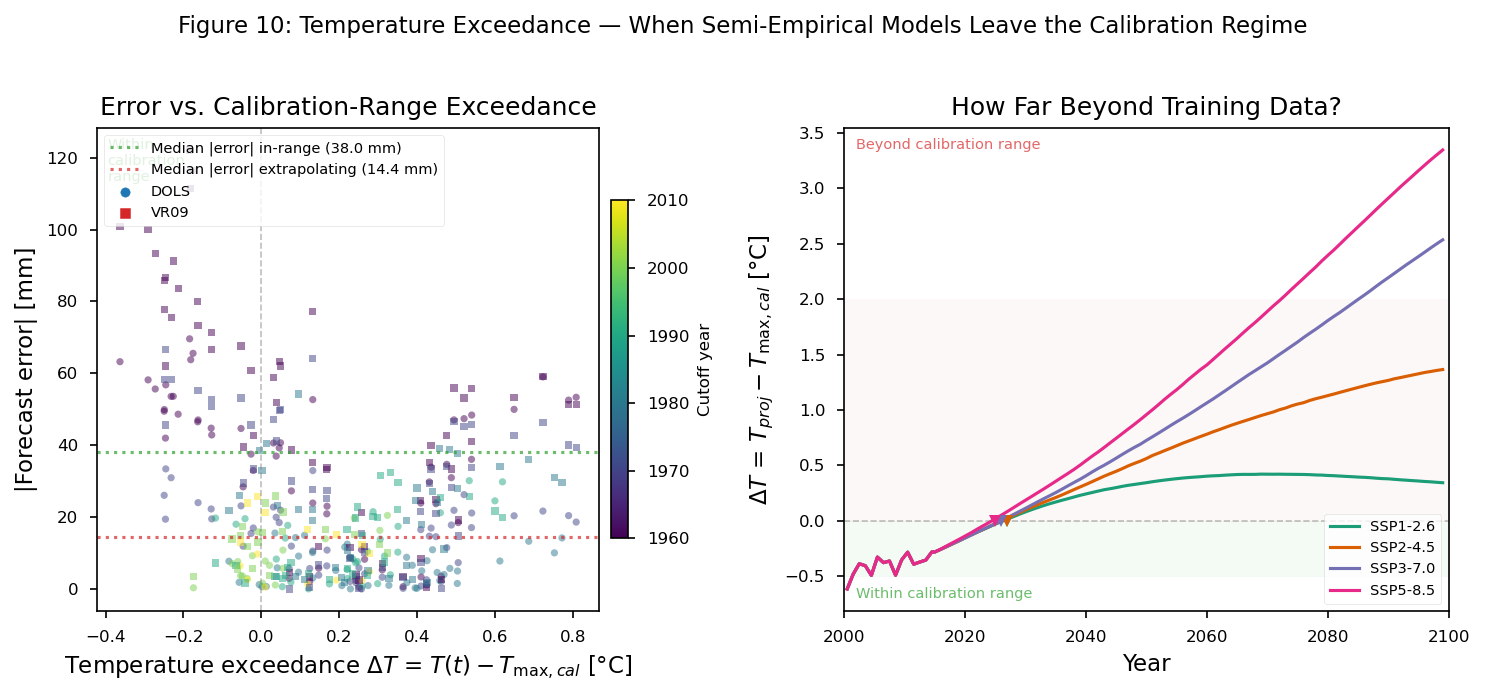


Temperature exceedance summary:
  Full calibration T_max (1920–2018): 0.492 °C (Berkeley 1995-2005 baseline)
  SSP1-2.6: enters extrapolation at 2027, ΔT at 2100 = +0.34 °C
  SSP2-4.5: enters extrapolation at 2027, ΔT at 2100 = +1.36 °C
  SSP3-7.0: enters extrapolation at 2026, ΔT at 2100 = +2.53 °C
  SSP5-8.5: enters extrapolation at 2025, ΔT at 2100 = +3.34 °C

  Median |error| within calibration range: 38.0 mm  (n=98)
  Median |error| in extrapolation regime:  14.4 mm  (n=298)


In [149]:
# ============================================================
# Approach C: Temperature exceedance analysis
# ============================================================
# For each cutoff year, the calibration record has a maximum
# temperature T_max.  As we project forward, observed temperature
# eventually exceeds T_max — the model is extrapolating beyond
# the calibration regime.
#
# Question: does forecast error correlate with the degree of
# temperature exceedance ΔT = T(t) − T_max_cal?
#
# Dependencies: cells 3, 6 (temperature scenarios), 26 (degrad_*)
# ============================================================

# ---- Compute T exceedance for each cutoff ----
# Temperature is in Berkeley Earth 1995-2005 baseline (temp_annual)
T_ann = temp_annual['temperature'].values
yr_ann = temp_annual['year'].values

exceedance_dols = {}  # {cutoff: {'dT': array, 'abs_err': array, 'lead': array}}
exceedance_vr09 = {}

for cut_yr in DEGRAD_CUTOFFS:
    T_max_cal = np.max(T_ann[yr_ann <= cut_yr])

    # DOLS
    if cut_yr in degrad_dols:
        r = degrad_dols[cut_yr]
        verif_yrs = cut_yr + r['lead']
        T_verif = np.interp(verif_yrs, yr_ann, T_ann)
        dT = T_verif - T_max_cal
        exceedance_dols[cut_yr] = dict(
            dT=dT, abs_err=np.abs(r['error_mm']),
            lead=r['lead'], T_max=T_max_cal,
        )

    # VR09
    if cut_yr in degrad_vr09:
        r = degrad_vr09[cut_yr]
        verif_yrs = cut_yr + r['lead']
        T_verif = np.interp(verif_yrs, yr_ann, T_ann)
        dT = T_verif - T_max_cal
        exceedance_vr09[cut_yr] = dict(
            dT=dT, abs_err=np.abs(r['error_mm']),
            lead=r['lead'], T_max=T_max_cal,
        )

# Pool across cutoffs
all_dT_dols  = np.concatenate([e['dT'] for e in exceedance_dols.values()])
all_err_dols = np.concatenate([e['abs_err'] for e in exceedance_dols.values()])
all_dT_vr09  = np.concatenate([e['dT'] for e in exceedance_vr09.values()])
all_err_vr09 = np.concatenate([e['abs_err'] for e in exceedance_vr09.values()])

# ---- SSP temperature exceedance into the future ----
# How far beyond the FULL calibration record (1920–2018) does each
# SSP projection push the temperature?
T_max_full = np.max(T_ann[yr_ann <= 2018])
ssp_exceedance = {}
for ssp_name, df_ssp in full_temp_scenarios.items():
    yrs = df_ssp['decimal_year'].values
    T_ssp = df_ssp['temperature'].values
    dT_ssp = T_ssp - T_max_full
    ssp_exceedance[ssp_name] = dict(years=yrs, dT=dT_ssp)

# ============================================================
# Figure 10: Temperature exceedance
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# --- Left: scatter of |error| vs temperature exceedance ---
ax = axes[0]

cmap = plt.cm.viridis
norm = plt.Normalize(min(DEGRAD_CUTOFFS), max(DEGRAD_CUTOFFS))

for cut_yr in sorted(exceedance_dols.keys()):
    e = exceedance_dols[cut_yr]
    color = cmap(norm(cut_yr))
    ax.scatter(e['dT'], e['abs_err'], c=[color]*len(e['dT']),
               s=12, alpha=0.5, edgecolors='none')

for cut_yr in sorted(exceedance_vr09.keys()):
    e = exceedance_vr09[cut_yr]
    color = cmap(norm(cut_yr))
    ax.scatter(e['dT'], e['abs_err'], c=[color]*len(e['dT']),
               s=12, alpha=0.5, marker='s', edgecolors='none')

# Binned means (DOLS and VR09 combined for the regression)
all_dT = np.concatenate([all_dT_dols, all_dT_vr09])
all_err = np.concatenate([all_err_dols, all_err_vr09])

# Split into within-range and extrapolation
within = all_dT <= 0
extrap = all_dT > 0
if within.sum() > 3:
    ax.axhline(np.median(all_err[within]), color='tab:green', ls=':',
               lw=1.5, alpha=0.7, label=f'Median |error| in-range '
               f'({np.median(all_err[within]):.1f} mm)')
if extrap.sum() > 3:
    ax.axhline(np.median(all_err[extrap]), color='tab:red', ls=':',
               lw=1.5, alpha=0.7, label=f'Median |error| extrapolating '
               f'({np.median(all_err[extrap]):.1f} mm)')

ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.text(0.02, 0.98, 'Within\ncalibration\nrange', transform=ax.transAxes,
        va='top', ha='left', fontsize=7, color='tab:green', alpha=0.7)

# Dummy entries for legend
ax.scatter([], [], c='tab:blue', s=20, label='DOLS', marker='o')
ax.scatter([], [], c='tab:red', s=20, label='VR09', marker='s')

ax.set_xlabel(r'Temperature exceedance $\Delta T$ = $T(t) - T_{\max,cal}$ [°C]')
ax.set_ylabel('|Forecast error| [mm]')
ax.set_title('Error vs. Calibration-Range Exceedance')
ax.legend(fontsize=7, loc='upper left')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Cutoff year', fontsize=8)

# --- Right: SSP temperature exceedance into the future ---
ax = axes[1]
ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.axhspan(-0.5, 0, color='tab:green', alpha=0.05)
ax.axhspan(0, 2, color='tab:red', alpha=0.03)

ssp_colors = {
    'SSP1-2.6': '#1b9e77', 'SSP2-4.5': '#d95f02',
    'SSP3-7.0': '#7570b3', 'SSP5-8.5': '#e7298a',
}
for ssp_name in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
    if ssp_name in ssp_exceedance:
        se = ssp_exceedance[ssp_name]
        mask = (se['years'] >= 2000) & (se['years'] <= 2100)
        color = ssp_colors.get(ssp_name, 'gray')
        ax.plot(se['years'][mask], se['dT'][mask],
                color=color, lw=1.5, label=ssp_name)

# Mark when each SSP first enters extrapolation regime
for ssp_name in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
    if ssp_name in ssp_exceedance:
        se = ssp_exceedance[ssp_name]
        exceedance_idx = np.where(se['dT'] > 0)[0]
        if len(exceedance_idx) > 0:
            yr_exceed = se['years'][exceedance_idx[0]]
            color = ssp_colors.get(ssp_name, 'gray')
            ax.plot(yr_exceed, 0, 'v', color=color, ms=6, zorder=5)

ax.text(0.02, 0.02, 'Within calibration range', transform=ax.transAxes,
        fontsize=7, color='tab:green', alpha=0.7, va='bottom')
ax.text(0.02, 0.98, 'Beyond calibration range', transform=ax.transAxes,
        fontsize=7, color='tab:red', alpha=0.7, va='top')

ax.set_xlabel('Year')
ax.set_ylabel(r'$\Delta T$ = $T_{proj} - T_{\max,cal}$ [°C]')
ax.set_title('How Far Beyond Training Data?')
ax.set_xlim(2000, 2100)
ax.legend(fontsize=7, loc='lower right')

fig.suptitle('Figure 10: Temperature Exceedance — '
             'When Semi-Empirical Models Leave the Calibration Regime',
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig10_exceedance.png',
            dpi=200, bbox_inches='tight')
plt.show()

# Summary
print('\nTemperature exceedance summary:')
print(f'  Full calibration T_max (1920–2018): {T_max_full:.3f} °C '
      f'(Berkeley 1995-2005 baseline)')
for ssp_name in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
    if ssp_name in ssp_exceedance:
        se = ssp_exceedance[ssp_name]
        exc_idx = np.where(se['dT'] > 0)[0]
        yr_first = se['years'][exc_idx[0]] if len(exc_idx) > 0 else np.nan
        dT_2100 = np.interp(2100, se['years'], se['dT'])
        print(f'  {ssp_name}: enters extrapolation at {yr_first:.0f}, '
              f'ΔT at 2100 = {dT_2100:+.2f} °C')

print(f'\n  Median |error| within calibration range: '
      f'{np.median(all_err[within]):.1f} mm  (n={within.sum()})')
if extrap.sum() > 0:
    print(f'  Median |error| in extrapolation regime:  '
          f'{np.median(all_err[extrap]):.1f} mm  (n={extrap.sum()})')

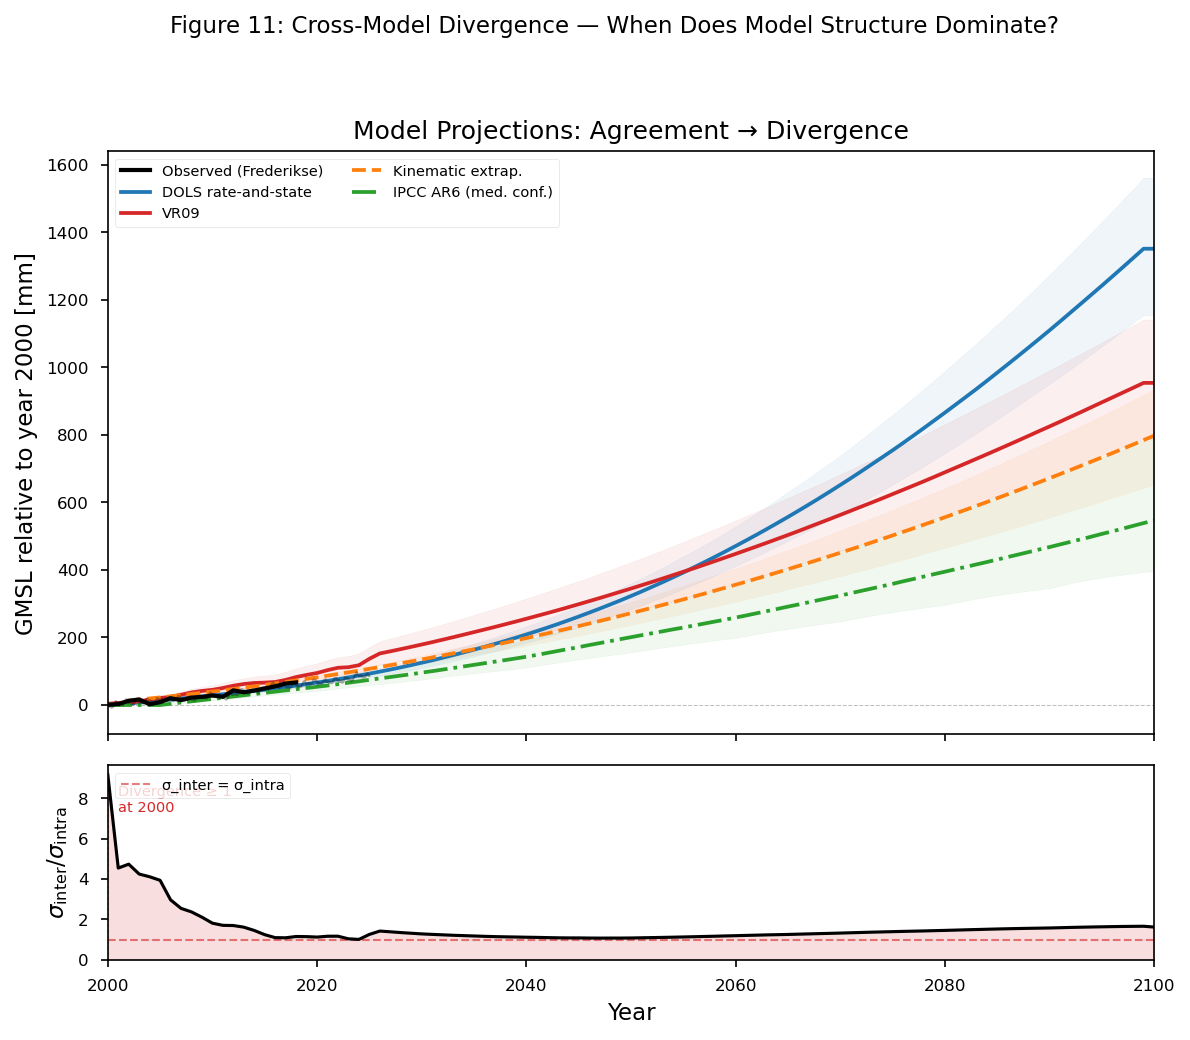


Cross-model divergence summary:

  Year 2030:
            DOLS:     125 mm  [109–139]
            VR09:     178 mm  [140–221]
       Kinematic:     134 mm  [122–146]
            IPCC:      95 mm  [74–126]
    σ_inter = 30 mm, σ_intra = 23 mm, ratio = 1.28

  Year 2050:
            DOLS:     322 mm  [282–360]
            VR09:     344 mm  [274–422]
       Kinematic:     271 mm  [237–304]
            IPCC:     200 mm  [155–273]
    σ_inter = 55 mm, σ_intra = 51 mm, ratio = 1.08

  Year 2075:
            DOLS:     754 mm  [652–859]
            VR09:     624 mm  [509–755]
       Kinematic:     502 mm  [422–578]
            IPCC:     358 mm  [275–508]
    σ_inter = 147 mm, σ_intra = 105 mm, ratio = 1.39

  Year 2100:
            DOLS:    1351 mm  [1155–1562]
            VR09:     954 mm  [788–1142]
       Kinematic:     797 mm  [653–935]
            IPCC:     546 mm  [396–798]
    σ_inter = 292 mm, σ_intra = 180 mm, ratio = 1.62

  Models first diverge (ratio ≥ 1) at year 2000


In [150]:
# ============================================================
# Approach D: Cross-model divergence
# ============================================================
# Compare four structurally different models:
#   1. DOLS rate-and-state (quadratic + disequilibrium)
#   2. VR09 (linear semi-empirical)
#   3. Kinematic extrapolation (quadratic in time)
#   4. IPCC AR6 process-model ensemble (SSP2-4.5)
#
# When models agree, we have confidence.  When they diverge,
# model structure matters more than calibration data — we have
# entered the regime of structural uncertainty.
#
# Divergence metric: σ_inter / σ_intra
#   σ_inter = std of model medians (inter-model spread)
#   σ_intra = mean CI half-width (average within-model unc.)
# When this ratio > 1, inter-model disagreement exceeds the
# average model's own uncertainty estimate.
#
# Dependencies: cells 6, 8, 20–21 (model ensembles), 16 (IPCC)
# ============================================================

# ============================================================
# Collect model projections on a common time grid (2000–2100)
# ============================================================
div_years = np.arange(2000, 2101, dtype=float)

def _interp_ensemble(ensemble, time, target_years):
    """Interpolate ensemble to target years, return (median, p5, p95)."""
    med = np.median(ensemble, axis=0)
    p5  = np.percentile(ensemble, 5, axis=0)
    p95 = np.percentile(ensemble, 95, axis=0)
    return (np.interp(target_years, time, med),
            np.interp(target_years, time, p5),
            np.interp(target_years, time, p95))

# 1. DOLS rate-and-state (obs + SSP2-4.5, from cell 20)
dols_med, dols_lo, dols_hi = _interp_ensemble(
    dols_ensemble, dols_time, div_years)

# 2. VR09 (obs + SSP2-4.5, from cell 21)
vr09_med, vr09_lo, vr09_hi = _interp_ensemble(
    vr09_ensemble, vr09_time, div_years)

# 3. Kinematic extrapolation (from cell 8)
kin_med = np.interp(div_years, t_extrap, quad_extrap)
kin_lo  = np.interp(div_years, t_extrap, quad_p5)
kin_hi  = np.interp(div_years, t_extrap, quad_p95)

# 4. IPCC AR6 medium-confidence ensemble (from cell 20)
ipcc_med_at = np.interp(div_years, med_years, np.median(med_conf_ensemble, axis=0))
ipcc_lo_at  = np.interp(div_years, med_years, np.percentile(med_conf_ensemble, 5, axis=0))
ipcc_hi_at  = np.interp(div_years, med_years, np.percentile(med_conf_ensemble, 95, axis=0))

# ============================================================
# Compute divergence metrics
# ============================================================
# Stack medians: (4, n_years)
model_medians = np.vstack([dols_med, vr09_med, kin_med, ipcc_med_at]) * M_TO_MM
model_los     = np.vstack([dols_lo, vr09_lo, kin_lo, ipcc_lo_at]) * M_TO_MM
model_his     = np.vstack([dols_hi, vr09_hi, kin_hi, ipcc_hi_at]) * M_TO_MM

# Inter-model spread: std of medians
sigma_inter = np.std(model_medians, axis=0, ddof=0)

# Intra-model uncertainty: mean CI half-width
ci_halfwidths = 0.5 * (model_his - model_los)
sigma_intra = np.mean(ci_halfwidths, axis=0)

# Divergence ratio
div_ratio = np.where(sigma_intra > 0, sigma_inter / sigma_intra, 0)

# ============================================================
# Figure 11: Cross-model divergence
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(9, 7), height_ratios=[3, 1],
                         sharex=True, gridspec_kw={'hspace': 0.08})

# --- Top: model projections ---
ax = axes[0]
ax.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)

# Observations
mask_f = (fred_time >= 2000) & (fred_time <= 2025)
ax.plot(fred_time[mask_f], fred_gmsl_rb[mask_f] * M_TO_MM,
        color='black', lw=2, zorder=10, label='Observed (Frederikse)')

# NASA satellite
mask_n = (nasa_time >= 2000) & (nasa_time <= 2025)
ax.plot(nasa_time[mask_n], nasa_gmsl_rb[mask_n] * M_TO_MM,
        color='black', lw=1, alpha=0.3, zorder=9)

MODEL_STYLES = {
    'DOLS':     dict(color='tab:blue',   lw=1.8, label='DOLS rate-and-state'),
    'VR09':     dict(color='tab:red',    lw=1.8, label='VR09'),
    'Kinematic':dict(color='tab:orange', lw=1.8, label='Kinematic extrap.', ls='--'),
    'IPCC':     dict(color='tab:green',  lw=1.8, label='IPCC AR6 (med. conf.)', ls='-.'),
}

for i, (name, style) in enumerate(MODEL_STYLES.items()):
    ax.plot(div_years, model_medians[i], **style)
    ax.fill_between(div_years, model_los[i], model_his[i],
                    color=style['color'], alpha=0.07)

ax.set_ylabel('GMSL relative to year 2000 [mm]')
ax.set_title('Model Projections: Agreement → Divergence')
ax.legend(fontsize=7, loc='upper left', ncol=2)
ax.set_xlim(2000, 2100)

# --- Bottom: divergence ratio ---
ax = axes[1]
ax.axhline(1.0, color='tab:red', ls='--', lw=1, alpha=0.6,
           label='σ_inter = σ_intra')
ax.fill_between(div_years, 0, div_ratio,
                where=div_ratio < 1, color='tab:green', alpha=0.15)
ax.fill_between(div_years, 0, div_ratio,
                where=div_ratio >= 1, color='tab:red', alpha=0.15)
ax.plot(div_years, div_ratio, color='black', lw=1.5)

# Find year when ratio first exceeds 1
exceed_idx = np.where(div_ratio >= 1.0)[0]
if len(exceed_idx) > 0:
    yr_exceed = div_years[exceed_idx[0]]
    ax.axvline(yr_exceed, color='tab:red', ls=':', lw=1, alpha=0.5)
    ax.text(yr_exceed + 1, ax.get_ylim()[1]*0.9,
            f'Divergence ≥ 1\nat {yr_exceed:.0f}',
            fontsize=7, color='tab:red', va='top')

ax.set_xlabel('Year')
ax.set_ylabel(r'$\sigma_{\mathrm{inter}} / \sigma_{\mathrm{intra}}$')
ax.set_xlim(2000, 2100)
ax.set_ylim(bottom=0)
ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Figure 11: Cross-Model Divergence — '
             'When Does Model Structure Dominate?',
             fontsize=11, y=1.01)
fig.savefig('../figures/stats_v_process_fig11_divergence.png',
            dpi=200, bbox_inches='tight')
plt.show()

# Summary
print('\nCross-model divergence summary:')
for yr in [2030, 2050, 2075, 2100]:
    idx = np.argmin(np.abs(div_years - yr))
    print(f'\n  Year {yr}:')
    for j, name in enumerate(['DOLS', 'VR09', 'Kinematic', 'IPCC']):
        print(f'    {name:>12}: {model_medians[j, idx]:>7.0f} mm  '
              f'[{model_los[j, idx]:.0f}–{model_his[j, idx]:.0f}]')
    print(f'    σ_inter = {sigma_inter[idx]:.0f} mm, '
          f'σ_intra = {sigma_intra[idx]:.0f} mm, '
          f'ratio = {div_ratio[idx]:.2f}')

if len(exceed_idx) > 0:
    print(f'\n  Models first diverge (ratio ≥ 1) at year {yr_exceed:.0f}')
else:
    print('\n  Divergence ratio stays below 1.0 through 2100')